## Instructions to Run the Notebook
---

Follow the steps below to execute this notebook successfully.

### 1. Install Required Python Libraries
Ensure Python **3.8 or above** is installed.  
Install all required dependencies using the following command:

''' pip install pandas numpy openpyxl matplotlib seaborn statsmodels scikit-learn '''

### 2. Update Dataset File Path

Locate the cell where the dataset is loaded (using pd.read_csv())

Update the file path to point to the dataset location on your local machine.

# Step 1 : import the Libraries

In [1]:
# =========================================================
# IMPORTS
# =========================================================
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import joblib
from scipy.stats import randint, uniform
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
# Ignore warnings
warnings.filterwarnings("ignore")
# Display settings
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head()

,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
0,0,994.0,D-penicillamine,14939.0,F,N,N,N,N,0.9,227.0,3.02,40.0,663.0,93.0,69.0,244.0,9.9,2.0,C
1,1,2267.0,NaN,20089.0,F,NaN,NaN,NaN,N,0.7,NaN,3.29,NaN,NaN,NaN,NaN,209.0,10.3,3.0,C
2,2,4062.0,NaN,23376.0,F,NaN,NaN,NaN,N,0.8,NaN,3.01,NaN,NaN,NaN,NaN,388.0,11.1,4.0,C
3,3,1216.0,Placebo,20483.0,F,N,N,N,N,0.6,248.0,3.35,44.0,1072.0,55.8,108.0,493.0,10.5,3.0,C
4,4,2555.0,NaN,22280.0,F,NaN,NaN,NaN,N,1.1,NaN,3.64,NaN,NaN,NaN,NaN,109.0,10.5,1.0,C


# Step 2 : Initial Data Inspection

## Shape and Columns check

In [4]:
#shape and columns
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

Shape: (15000, 20)

Columns:
 ['id', 'N_Days', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage', 'Status']


## data Types and overview

In [5]:
#data types and overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             15000 non-null  int64  
 1   N_Days         15000 non-null  float64
 2   Drug           8411 non-null   object 
 3   Age            15000 non-null  float64
 4   Sex            15000 non-null  object 
 5   Ascites        8435 non-null   object 
 6   Hepatomegaly   8415 non-null   object 
 7   Spiders        8408 non-null   object 
 8   Edema          15000 non-null  object 
 9   Bilirubin      15000 non-null  float64
 10  Cholesterol    6629 non-null   float64
 11  Albumin        15000 non-null  float64
 12  Copper         8295 non-null   float64
 13  Alk_Phos       8405 non-null   float64
 14  SGOT           8407 non-null   float64
 15  Tryglicerides  6583 non-null   float64
 16  Platelets      14401 non-null  float64
 17  Prothrombin    14980 non-null  float64
 18  Stage 

Numerical Features: ['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']

Categorical Features: ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']

Target Variable : ['Status']

## Initial Deascriptive statistics

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,15000.0,7499.500000,4330.271354,0.00,3749.75,7499.50,11249.25,14999.00
N_Days,15000.0,1973.730920,1460.071124,0.80,1092.00,1776.00,2615.00,40440.00
Age,15000.0,19275.442733,3749.605188,94.00,16714.00,19544.00,22336.00,129325.00
Bilirubin,15000.0,1.875513,2.780582,0.30,0.70,0.90,1.80,28.00
Cholesterol,6629.0,325.740987,179.617492,120.00,239.00,280.00,350.00,1794.00
Albumin,15000.0,3.524087,0.370869,1.96,3.29,3.58,3.77,4.64
Copper,8295.0,74.931831,74.030658,0.90,32.00,52.00,88.00,1273.00
Alk_Phos,8405.0,1638.171374,1819.016193,19.00,718.00,1072.00,1664.00,16802.00
SGOT,8407.0,106.383697,51.318388,26.35,71.00,97.65,131.75,614.00
Tryglicerides,6583.0,110.052575,48.796854,33.00,80.00,99.00,133.00,598.00


###  Insights from Descriptive Statistics

#### General Observations

- The dataset contains **15,000 observations**, indicating sufficient data for training robust models.
- Several variables have **lower counts than total observations**, indicating the presence of **missing values**, particularly in:
  - Cholesterol
  - Tryglicerides
  - Copper
  - Alk_Phos
  - SGOT

---

#### Missing Values Insight

- Cholesterol and Tryglicerides have **more than 50% missing values**, which is significant.
- Copper, Alk_Phos, and SGOT also have **substantial missingness (~40–45%)**.
- This suggests the need for **careful imputation strategies**, rather than dropping these variables.

---

#### Distribution & Skewness

- Several variables such as:
  - Bilirubin
  - Alk_Phos
  - Copper
  - Tryglicerides  
  show **high standard deviation and extreme maximum values**, indicating **right-skewed distributions**.

- For example:
  - Bilirubin: median = 0.9, max = 28 → strong skew
  - Alk_Phos: median ≈ 1072, max = 16802 → extreme skew

- This suggests the need for:
  - **log transformation**
  - or **outlier treatment**

---

#### Outlier Detection (From Summary Stats)

- Several features contain **extreme values**, likely outliers:
  - Cholesterol (max = 1794)
  - Copper (max = 1273)
  - Alk_Phos (max = 16802)
  - Platelets (max = 3092)
  - N_Days (max = 40440)

- These values are significantly higher than the 75th percentile, confirming **presence of outliers**.

---

#### Age Feature Insight

- Age appears to be recorded in **days**, not years.
- The maximum value (129,325 days ≈ 354 years) is **unrealistic**, indicating:
  - potential data entry errors
  - or extreme outliers

- This feature requires:
  - conversion to years
  - and possible outlier handling

---

#### Stable Features

- Albumin and Prothrombin show:
  - relatively **low standard deviation**
  - smaller range between min and max

- This suggests:
  - more **stable distributions**
  - fewer extreme values

---

#### Stage Variable

- Stage ranges from **1 to 4**, with a mean of approximately 3.
- This indicates:
  - most patients are in **moderate to advanced stages**
- Stage should be treated as an **ordinal feature** rather than purely numerical.

---

#### Overall Conclusion

- The dataset contains:
  - significant missing values
  - skewed distributions
  - extreme outliers

- These observations justify the need for:
  - **median imputation**
  - **outlier capping**
  - **log transformation for skewed features**

These preprocessing steps will help improve model stability and predictive performance.

## Missing And Duplicate Values check

In [7]:
# missing values  and duplicate checks
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("Missing values:\n")
print(missing)
# Duplicate check 
print("Duplicate rows:", df.duplicated().sum())

Missing values:

Tryglicerides    8417
Cholesterol      8371
Copper           6705
Alk_Phos         6595
SGOT             6593
Spiders          6592
Drug             6589
Hepatomegaly     6585
Ascites          6565
Platelets         599
Prothrombin        20
dtype: int64
Duplicate rows: 0


no duplicate values but There are missing values we will take care of this in the later stage of the notebook
### Observations from Numerical Features
- Several features such as Cholesterol, Tryglicerides, Copper, Alk_Phos, and SGOT contain a high proportion of missing values (>40%).
- Age appears to be recorded in days and contains extreme values, indicating possible data quality issues.
- Many biochemical features (e.g., Bilirubin, Alk_Phos, Platelets) show strong right-skewness and extreme outliers.
- Stage is an ordinal feature ranging from 1 to 4 and should be treated accordingly.
- Some variables contain unrealistic maximum values, suggesting the need for outlier handling.

## Unique Values check

In [8]:
#unique values check
for column in df.columns:
    print(f"Unique values in '{column}':")
    print(df[column].unique())
    print("-" * 40)

Unique values in 'id':
[    0     1     2 ... 14997 14998 14999]
----------------------------------------
Unique values in 'N_Days':
[9.9400e+02 2.2670e+03 4.0620e+03 1.2160e+03 2.5550e+03 3.0590e+03
 3.2600e+02 2.1030e+03 2.2100e+02 3.6110e+03 2.1780e+03 2.2560e+03
 9.3900e+02 3.4220e+03 4.5560e+03 2.2940e+03 7.9000e+02 1.4010e+03
 2.1700e+03 6.2500e+02 1.1500e+03 1.3290e+03 2.5040e+03 1.3670e+03
 4.1840e+03 2.6440e+03 2.5270e+03 2.2490e+03 1.4080e+03 1.2950e+03
 3.5810e+03 1.1100e+02 1.9250e+03 2.2020e+03 4.8900e+02 1.1490e+03
 1.6150e+03 1.1030e+03 2.2880e+03 2.4900e+02 5.9700e+02 1.6390e+03
 4.4530e+03 9.8900e+02 1.1530e+03 1.0950e+03 2.5800e+03 3.1570e+03
 2.5630e+03 5.3300e+02 2.4560e+03 6.9100e+02 1.9800e+03 7.7800e+02
 2.0550e+03 3.6720e+03 1.2360e+03 2.6980e+03 1.7850e+03 7.8600e+02
 3.9920e+03 7.0800e+02 1.4190e+03 3.0690e+03 3.2310e+03 1.0000e+03
 2.8550e+03 2.8470e+03 2.5760e+03 2.3500e+03 1.6530e+03 3.4580e+03
 2.8120e+03 3.0920e+03 3.4920e+03 1.0860e+03 3.8500e+03 1.4340e

### Feature Classification

#### Target Variable

- **Status**
  - Type: Categorical
  - Description: Represents the outcome with three classes:
    - C
    - D
    - CL

---

####  Numerical Variables

The following features are numerical:

- N_Days  
- Age  
- Bilirubin  
- Cholesterol  
- Albumin  
- Copper  
- Alk_Phos  
- SGOT  
- Tryglicerides  
- Platelets  
- Prothrombin  
- Stage  

> Note:  
> - **Stage** is numerical but represents an **ordinal category (1–4)**.

---

#### Categorical Variables

The following features are categorical:

- Drug  
- Sex  
- Ascites  
- Hepatomegaly  
- Spiders  
- Edema  

---

#### Columns to Drop

- id  
  - Reason: It is a unique identifier and does not contribute to prediction.

---

####  Summary

- Target Variable: 1  
- Numerical Features: 12  
- Categorical Features: 6  
- Columns Dropped: 1  


## check Unique Values and Counts for Categorical variables

In [9]:
combined = []
cols =  ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']
for col in cols:
    counts = df[col].value_counts(dropna=False)
    percentages = df[col].value_counts(dropna=False, normalize=True) * 100

    temp = pd.DataFrame({
        'column': col,
        'value': counts.index,
        'count': counts.values,
        'percentage': percentages.values.round(2)
    })

    combined.append(temp)

combined_df = pd.concat(combined, ignore_index=True)

combined_df


,column,value,count,percentage
0,Drug,NaN,6589,43.93
1,Drug,D-penicillamine,4496,29.97
2,Drug,Placebo,3915,26.10
3,Sex,F,14351,95.67
4,Sex,M,649,4.33
5,Ascites,N,8062,53.75
6,Ascites,NaN,6565,43.77
7,Ascites,Y,372,2.48
8,Ascites,F,1,0.01
9,Hepatomegaly,NaN,6585,43.90


As we can see in the Ascites columns there is "f" for a single record which is a data error so we will replace it with blank

In [10]:
#replacing "f" in single record with blank 
df["Ascites"] = df["Ascites"].replace("f", np.nan)

## Age Transformation : from days to Year

In [11]:
df["Age"] = df["Age"] / 365

As we have seen the age was in days, so we are converting it into year for the better understanding

In [12]:
df.head()

,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
0,0,994.0,D-penicillamine,40.928767,F,N,N,N,N,0.9,227.0,3.02,40.0,663.0,93.0,69.0,244.0,9.9,2.0,C
1,1,2267.0,NaN,55.038356,F,NaN,NaN,NaN,N,0.7,NaN,3.29,NaN,NaN,NaN,NaN,209.0,10.3,3.0,C
2,2,4062.0,NaN,64.043836,F,NaN,NaN,NaN,N,0.8,NaN,3.01,NaN,NaN,NaN,NaN,388.0,11.1,4.0,C
3,3,1216.0,Placebo,56.117808,F,N,N,N,N,0.6,248.0,3.35,44.0,1072.0,55.8,108.0,493.0,10.5,3.0,C
4,4,2555.0,NaN,61.041096,F,NaN,NaN,NaN,N,1.1,NaN,3.64,NaN,NaN,NaN,NaN,109.0,10.5,1.0,C


## Dropping the "ID" Columns

In [13]:
## dropping the ID columns
df = df.drop(columns=["id"])

In [14]:
df.head()

,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
0,994.0,D-penicillamine,40.928767,F,N,N,N,N,0.9,227.0,3.02,40.0,663.0,93.0,69.0,244.0,9.9,2.0,C
1,2267.0,NaN,55.038356,F,NaN,NaN,NaN,N,0.7,NaN,3.29,NaN,NaN,NaN,NaN,209.0,10.3,3.0,C
2,4062.0,NaN,64.043836,F,NaN,NaN,NaN,N,0.8,NaN,3.01,NaN,NaN,NaN,NaN,388.0,11.1,4.0,C
3,1216.0,Placebo,56.117808,F,N,N,N,N,0.6,248.0,3.35,44.0,1072.0,55.8,108.0,493.0,10.5,3.0,C
4,2555.0,NaN,61.041096,F,NaN,NaN,NaN,N,1.1,NaN,3.64,NaN,NaN,NaN,NaN,109.0,10.5,1.0,C


# Step 3 : Data Cleaning 

## Fix inconsistent values and correcting the data Types

In [15]:
# strip spaces + lowercase
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip().str.lower()

In [16]:
## Correct data type 
df.info()
# Convert categorical columns explicitly
cat_cols = ["Drug", "Sex", "Ascites", "Hepatomegaly", "Spiders", "Edema"]

for col in cat_cols:
    df[col] = df[col].astype("category")
df["Stage"] = df["Stage"].astype("int")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   N_Days         15000 non-null  float64
 1   Drug           8411 non-null   object 
 2   Age            15000 non-null  float64
 3   Sex            15000 non-null  object 
 4   Ascites        8435 non-null   object 
 5   Hepatomegaly   8415 non-null   object 
 6   Spiders        8408 non-null   object 
 7   Edema          15000 non-null  object 
 8   Bilirubin      15000 non-null  float64
 9   Cholesterol    6629 non-null   float64
 10  Albumin        15000 non-null  float64
 11  Copper         8295 non-null   float64
 12  Alk_Phos       8405 non-null   float64
 13  SGOT           8407 non-null   float64
 14  Tryglicerides  6583 non-null   float64
 15  Platelets      14401 non-null  float64
 16  Prothrombin    14980 non-null  float64
 17  Stage          15000 non-null  float64
 18  Status

# Step 4 : Exploratory Data Analysis

##### Exploratory Data Analysis (EDA)

EDA is performed on the cleaned dataset (without imputation or outlier treatment) 
to understand:

- Data distributions  
- Missing patterns  
- Feature-target relationships  
- Presence of outliers  

This step helps in making data-driven preprocessing decisions.

In [17]:
# Defining the numerical, Categorical and target variables
target = "Status"
num_cols = [ "N_Days", "Age", "Bilirubin", "Cholesterol", "Albumin", "Copper", "Alk_Phos", "SGOT", "Tryglicerides","Platelets", "Prothrombin"]
cat_cols = ["Drug", "Sex", "Ascites", "Hepatomegaly", "Spiders", "Edema"]
ordinal_cols = ["Stage"]

## 4.1 Univariate Analysis

### 1. Target Variable Distribution

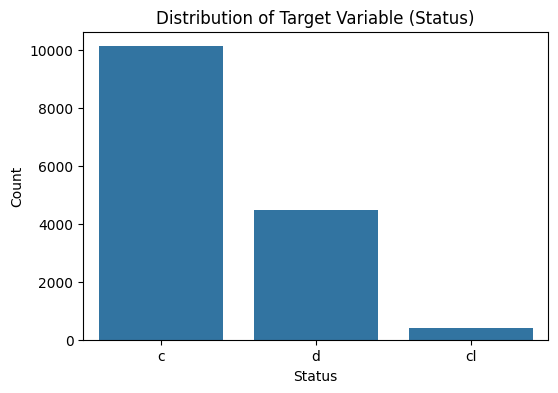

Status
c     67.446667
d     29.926667
cl     2.626667
Name: proportion, dtype: float64


In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x=target, data=df)
plt.title("Distribution of Target Variable (Status)")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

print(df[target].value_counts(normalize=True) * 100)

#### Target Variable Analysis (Status)

- The target variable exhibits a **clear class imbalance**.

- Class distribution:
  - C ≈ 67.4% (majority class)
  - D ≈ 29.9%
  - CL ≈ 2.6% (minority class)

- The dataset is heavily dominated by class **C**, while class **CL** is significantly underrepresented.

---

##### Implications

- Models trained on this dataset may become **biased toward the majority class (C)**.
- The minority class (**CL**) may be **poorly predicted**, leading to low recall for that class.

---

##### Modeling Considerations

To address class imbalance, the following strategies should be considered:

- Use **class weights** in models (e.g., Logistic Regression, Random Forest)
- Apply **SMOTE or other resampling techniques** (only on training data)
- Evaluate models using:
  - **Precision**
  - **Recall**
  - **F1-score**
  - **Confusion matrix**
  - instead of relying only on accuracy

---

##### Conclusion

The presence of class imbalance must be accounted for during model training and evaluation to ensure fair and reliable predictions across all classes.

### 2. Numerical Variables — Histograms + KDE

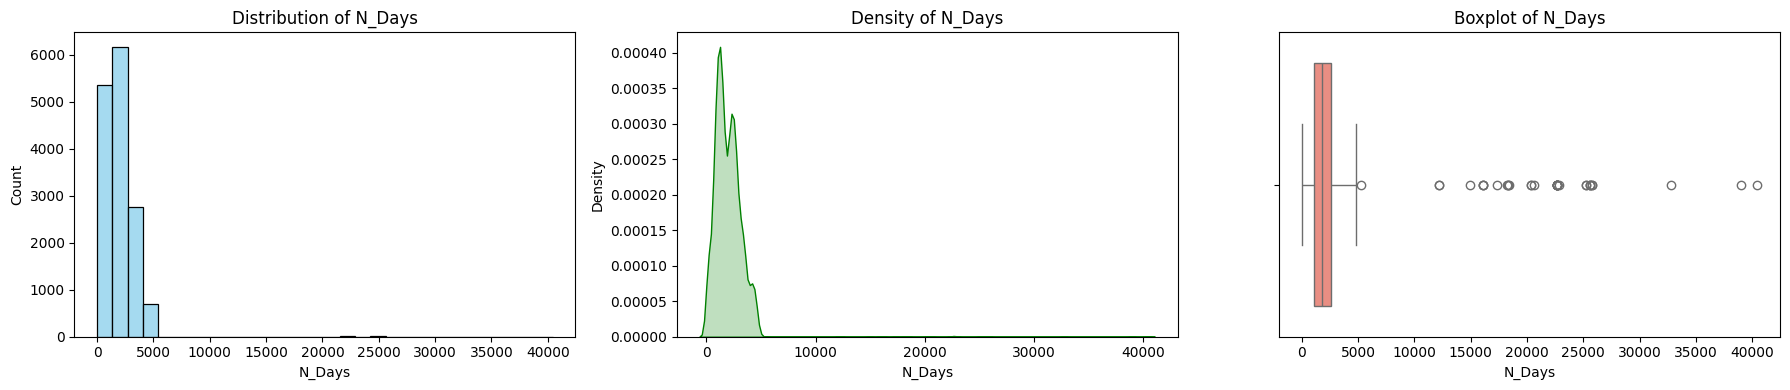

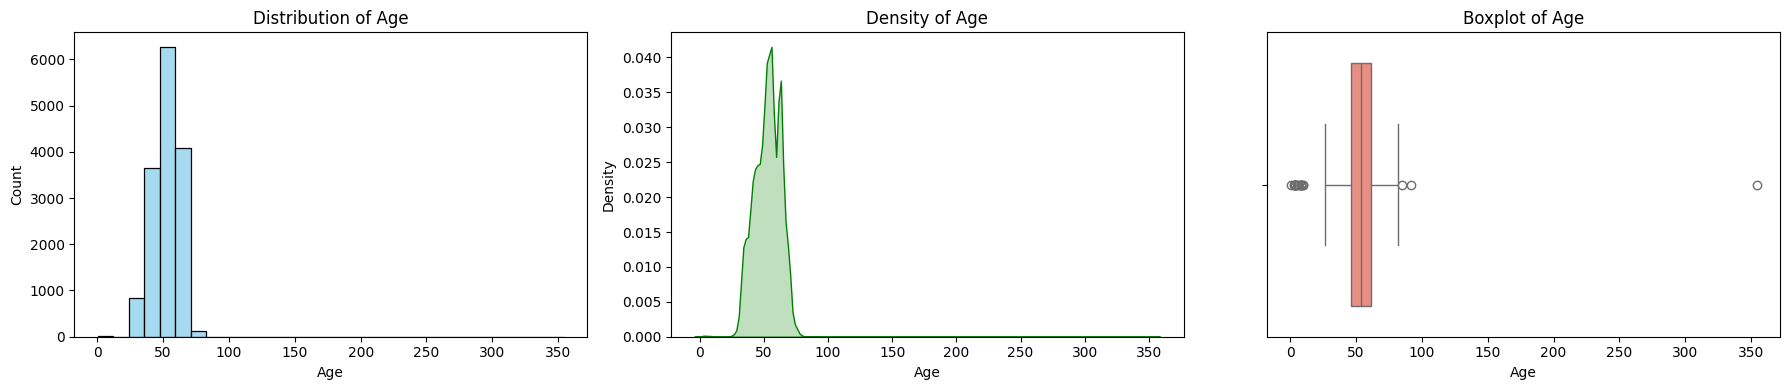

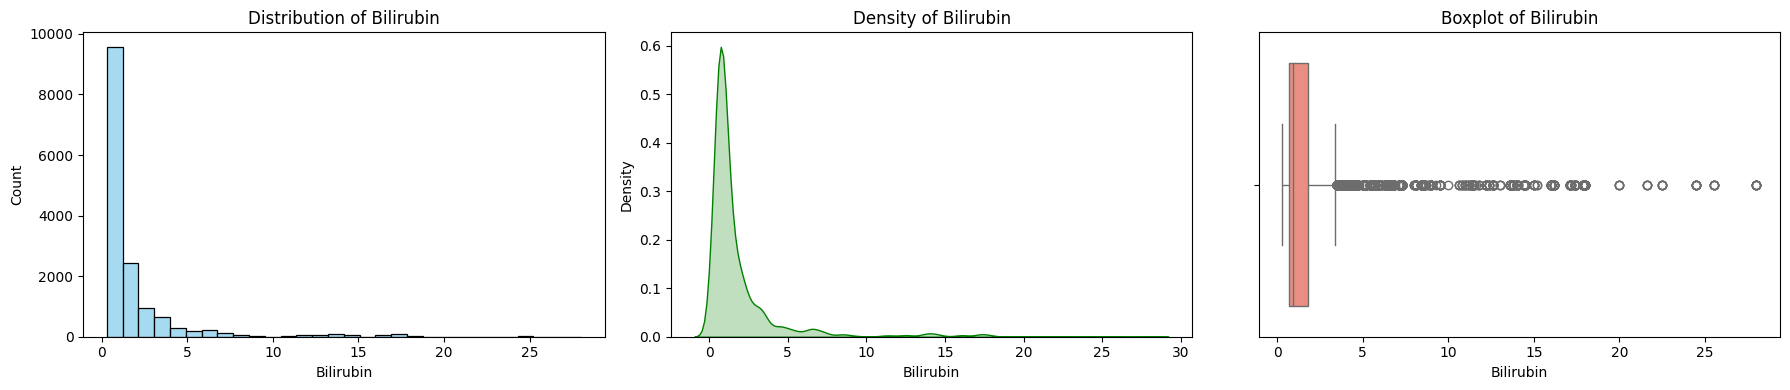

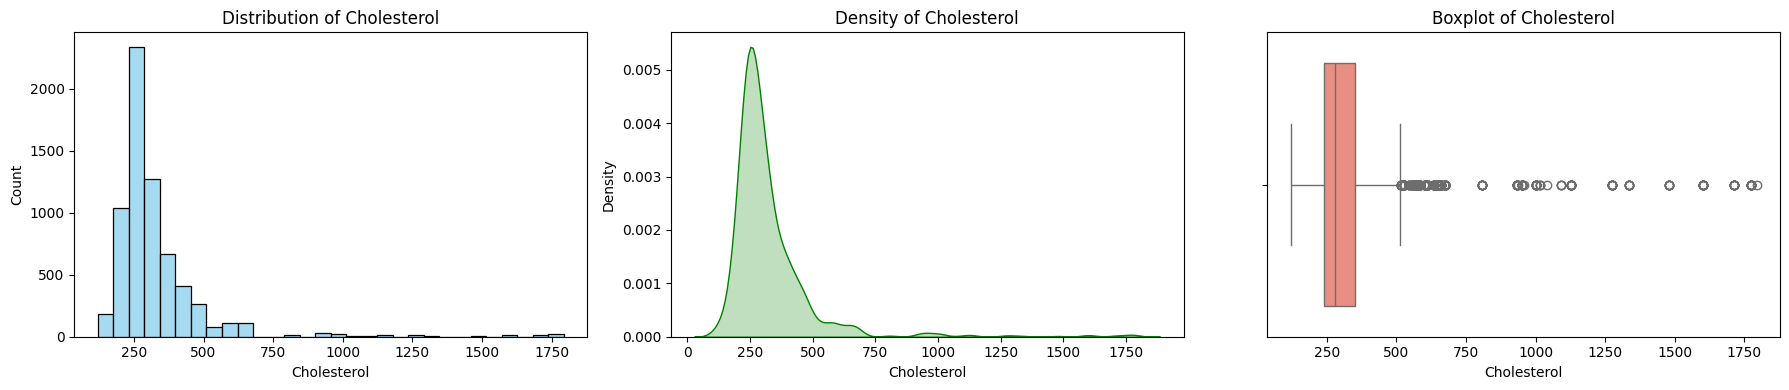

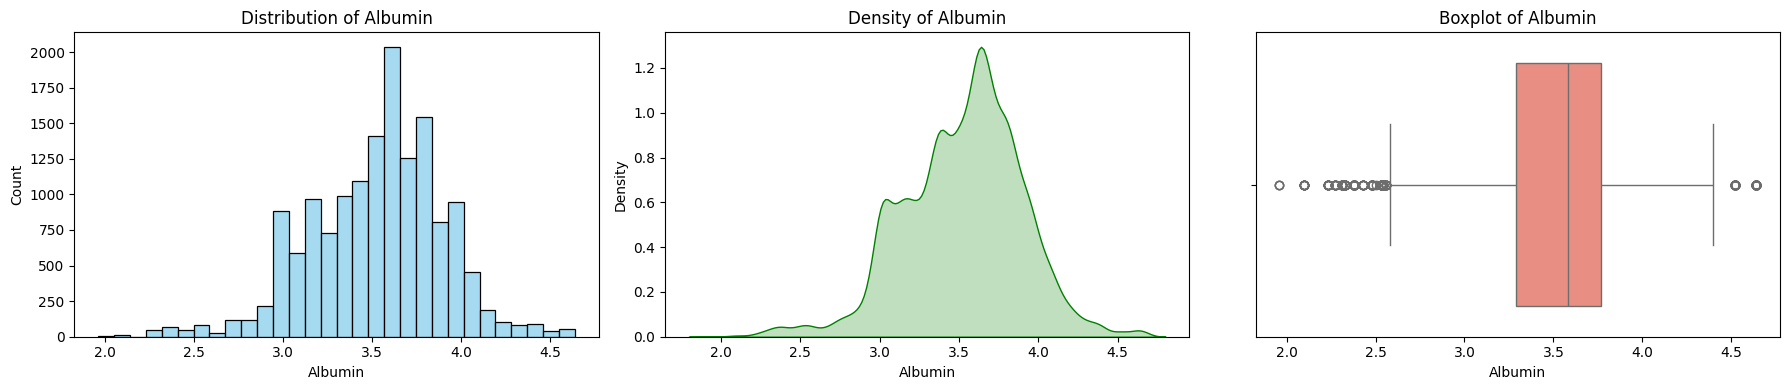

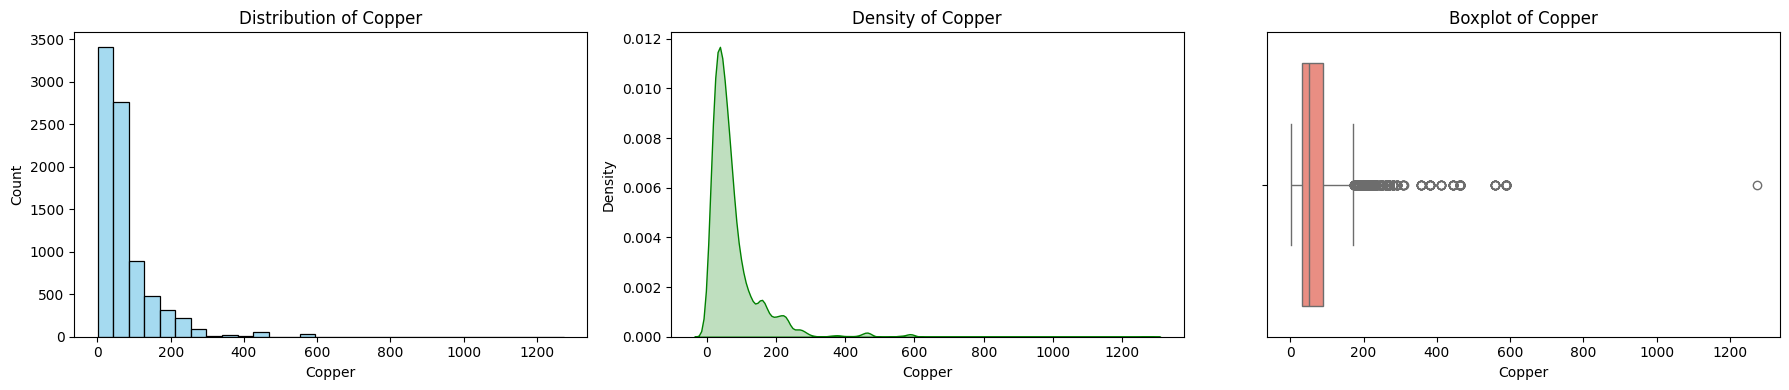

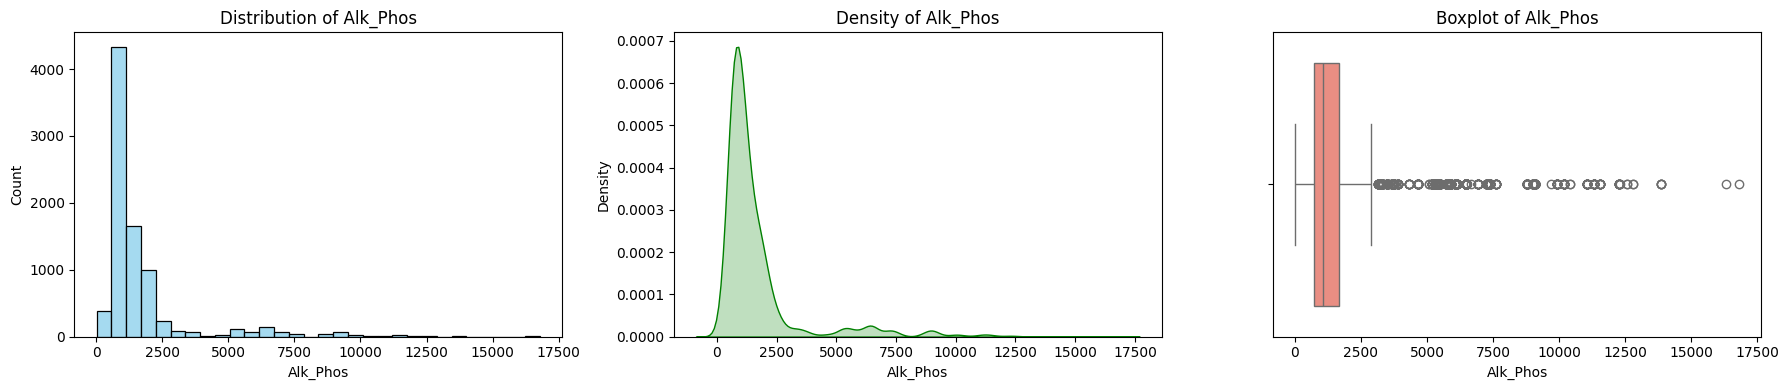

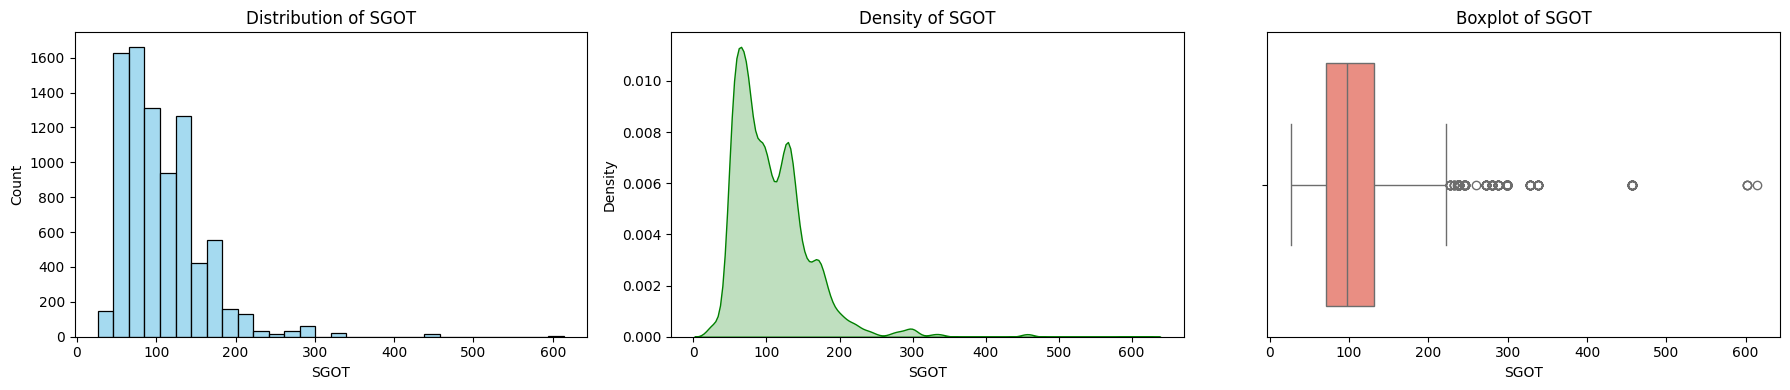

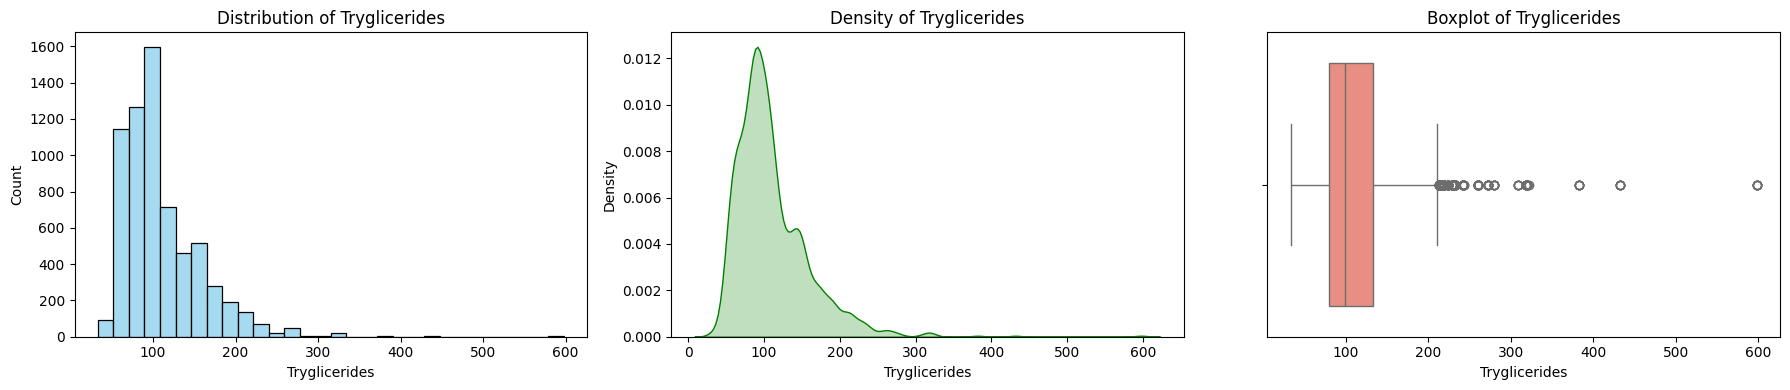

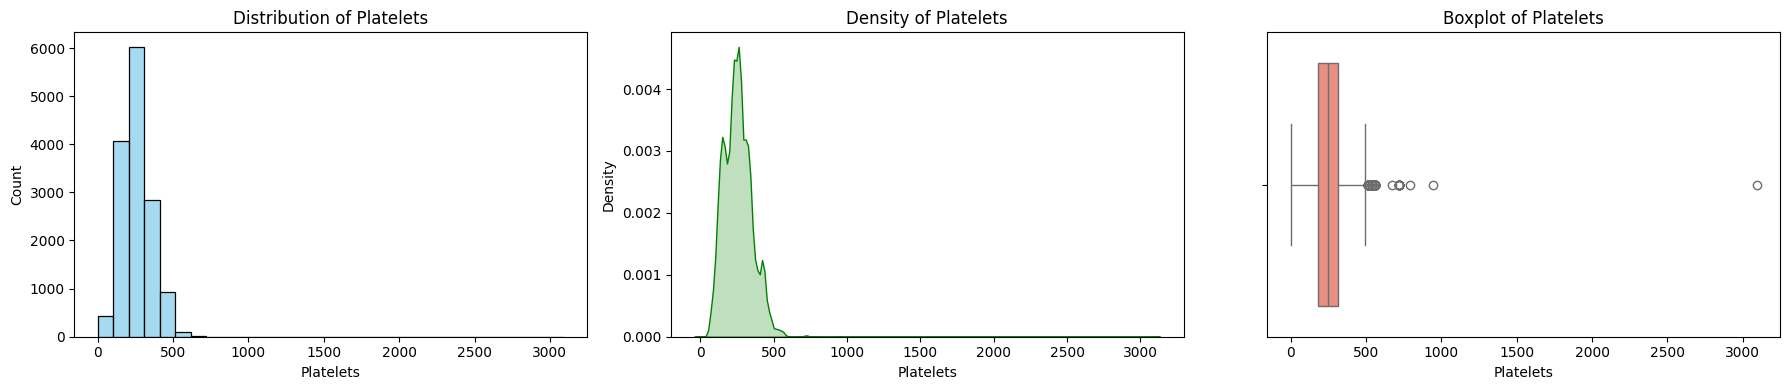

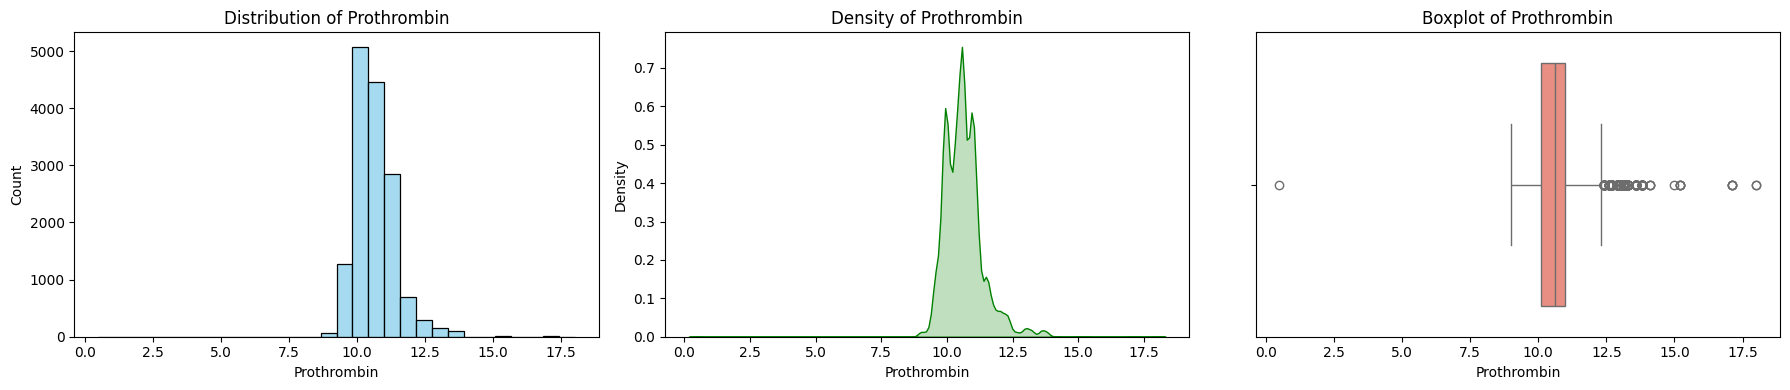

In [19]:
for col in num_cols:
    plt.figure(figsize=(18, 4))
    
    data = df[col].dropna()

    # Histogram
    plt.subplot(1, 3, 1)
    sns.histplot(data, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    
    # KDE Plot
    plt.subplot(1, 3, 2)
    sns.kdeplot(data, fill=True, color='green')
    plt.title(f'Density of {col}')
    
    # Boxplot
    plt.subplot(1, 3, 3)
    sns.boxplot(x=data, color='salmon')
    plt.title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

#### Univariate Analysis Insights (Numerical Variables)

##### Overall Pattern

- Most numerical variables exhibit **right-skewed distributions**, indicating that a large number of observations are concentrated at lower values with a long tail toward higher values.
- Boxplots confirm the presence of **significant outliers across multiple variables**, especially in biochemical markers.

---

#####  N_Days

- Distribution is **heavily right-skewed**, with most values concentrated below 5000.
- Boxplot shows **extreme high-value outliers**, indicating a few patients with very long follow-up durations.
- Suggests potential need for **outlier capping or transformation**.

---

##### Age

- Age distribution appears approximately **normally distributed**, centered around middle-aged individuals.
- However, the presence of **extreme values (e.g., above 100 years and up to ~350 years)** indicates unrealistic observations.
- These values are likely due to **data entry errors or anomalies**, not unit inconsistencies.
- Therefore, **outlier treatment (e.g., capping or removal)** is required for this feature.

---

##### Bilirubin

- Strong **right-skewness** observed.
- Majority of values are concentrated at very low levels, with a long tail extending to high values.
- Boxplot shows **numerous extreme outliers**, indicating variability in disease severity.
- Log transformation is likely required.

---

##### Cholesterol

- Moderately right-skewed distribution.
- Most observations fall between 200–400, but extreme values extend beyond 1500.
- Presence of **clear outliers**, suggesting need for capping.

---

##### Albumin

- Distribution appears **approximately normal**, with slight skewness.
- Boxplot shows **few outliers**, indicating relatively stable behavior.
- Likely does not require heavy transformation.

---

##### Copper

- Highly **right-skewed distribution** with a long tail.
- Significant number of **extreme outliers**, reaching very high values.
- Indicates strong variability → requires **log transformation and/or capping**.

---

##### Alk_Phos

- Extremely **right-skewed distribution**.
- Very large spread with extreme values reaching very high levels.
- Boxplot shows **heavy outlier presence**, making it one of the most skewed variables.
- Strong candidate for **log transformation**.

---

##### SGOT

- Moderately right-skewed.
- Some high-value outliers observed.
- Distribution is less extreme compared to Alk_Phos and Copper but still requires treatment.

---

##### Tryglicerides

- Right-skewed distribution with most values around 80–150.
- Outliers present but not as extreme as other biochemical variables.
- Mild transformation may be sufficient.

---

##### Platelets

- Slight right skew with majority of values clustered.
- However, **extreme outliers exist (very high values)**.
- Requires outlier handling.

---

##### Prothrombin

- Distribution is **close to normal**, centered around 10–11.
- Few outliers present, but overall stable.
- Likely requires minimal preprocessing.

---

##### Overall Conclusion

- Majority of variables are **right-skewed with significant outliers**.
- A few variables (Albumin, Prothrombin) are relatively stable.
- These observations justify:
  - **median imputation (robust to outliers)**
  - **log transformation for highly skewed variables**
  - **outlier capping (e.g., 1st–99th percentile)**

These preprocessing steps will help improve model performance and stability.

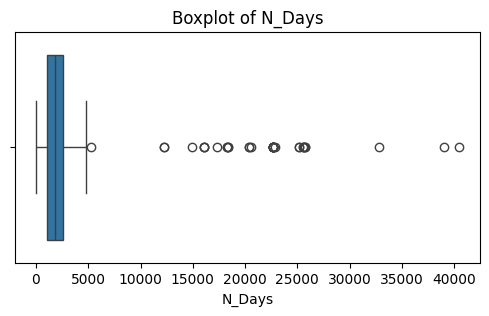

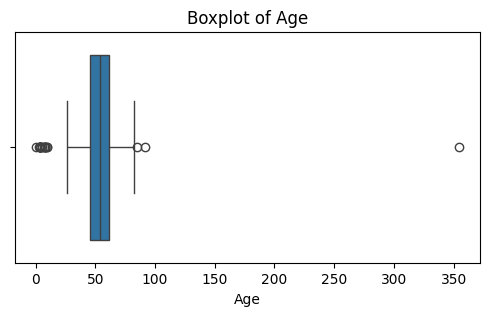

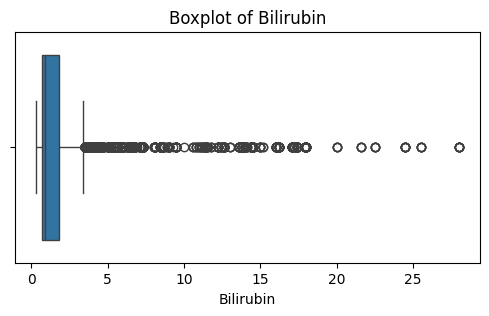

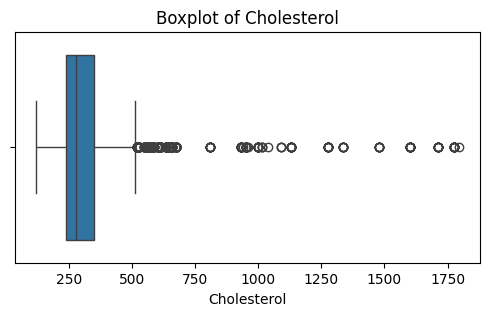

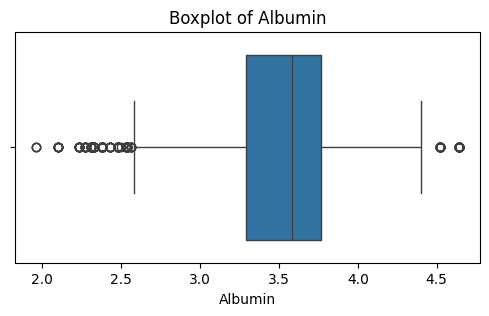

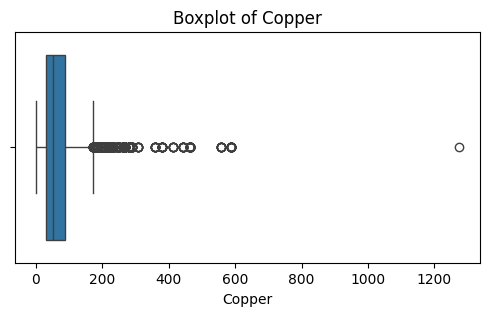

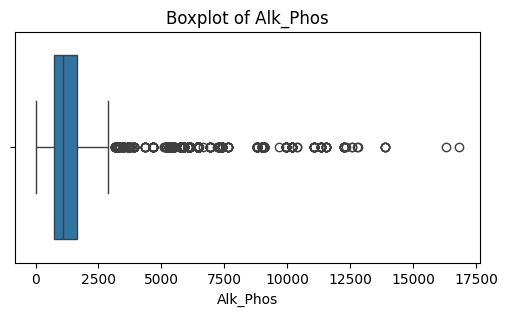

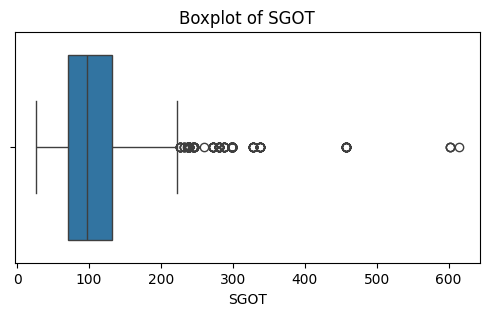

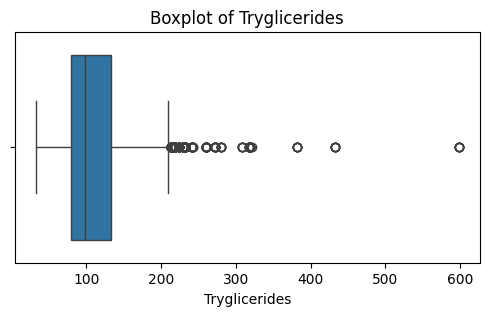

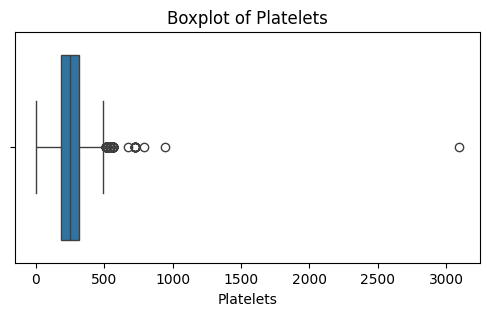

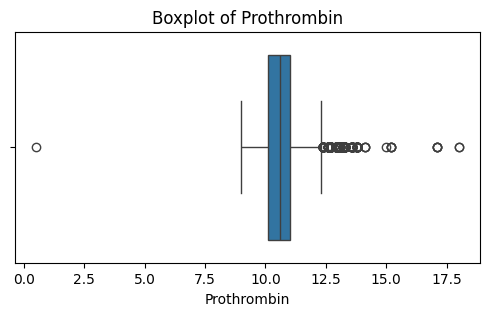

In [20]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

### 3. Categorical Variables

#### Missing values visualization

Before proceeding with further analysis, it is important to examine the extent of missing values in the dataset.

This helps in:
- identifying problematic features
- guiding imputation strategies
- understanding data quality

Missing Values Summary:
Tryglicerides    8417
Cholesterol      8371
Copper           6705
Alk_Phos         6595
SGOT             6593
Spiders          6592
Drug             6589
Hepatomegaly     6585
Ascites          6565
Platelets         599
Prothrombin        20
dtype: int64


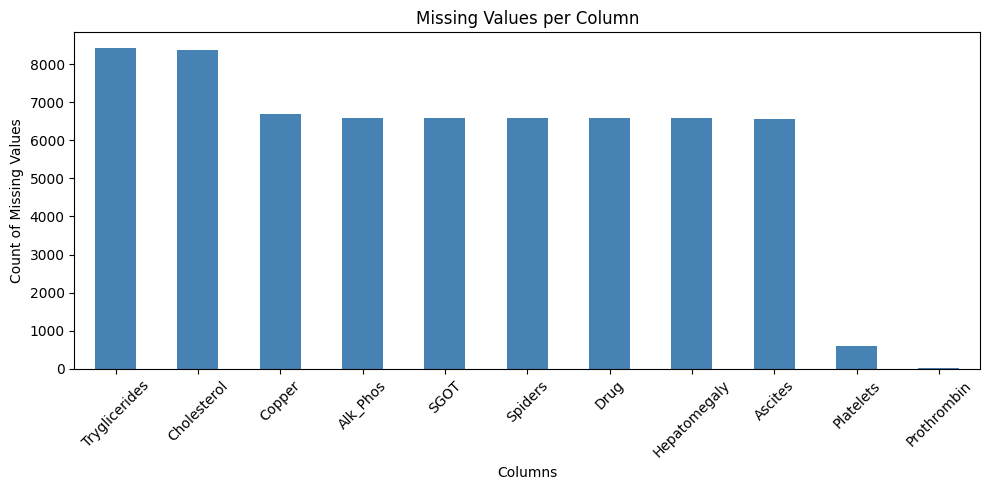

In [21]:
# Missing values summary
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("Missing Values Summary:")
print(missing)

# Missing values bar chart
if len(missing) > 0:
    plt.figure(figsize=(10, 5))
    missing.plot(kind="bar", color="steelblue")
    plt.title("Missing Values per Column")
    plt.xlabel("Columns")
    plt.ylabel("Count of Missing Values")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values present in the dataset.")

##### Insights:

- Several variables such as Cholesterol, Tryglicerides, Copper, Alk_Phos, and SGOT contain significant missing values.
- Missing values are unevenly distributed across features and will require appropriate imputation strategies.

#### Univariate analysis for categorical variables


Categorical Feature: Drug

Frequency Table:
              Drug  count  percentage
0              NaN   6589   43.926667
1  d-penicillamine   4496   29.973333
2          placebo   3915   26.100000


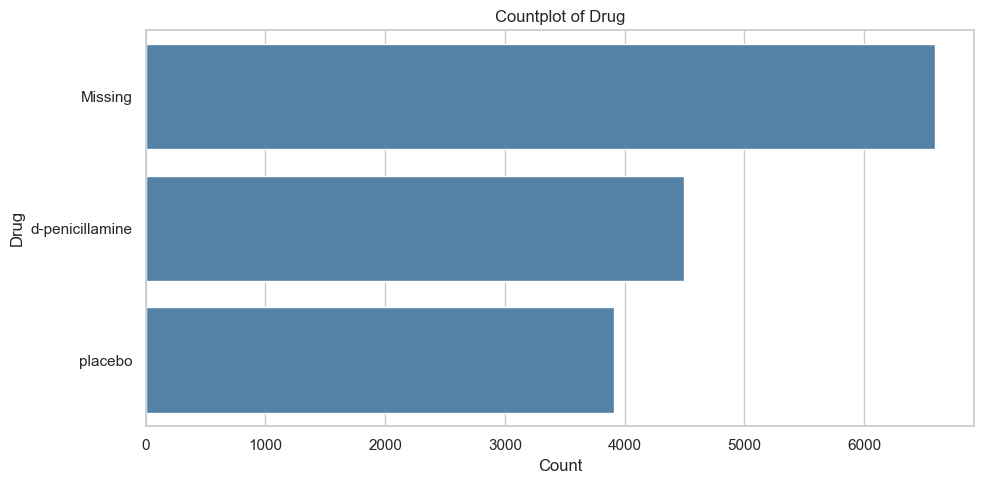


Categorical Feature: Sex

Frequency Table:
  Sex  count  percentage
0   f  14351   95.673333
1   m    649    4.326667


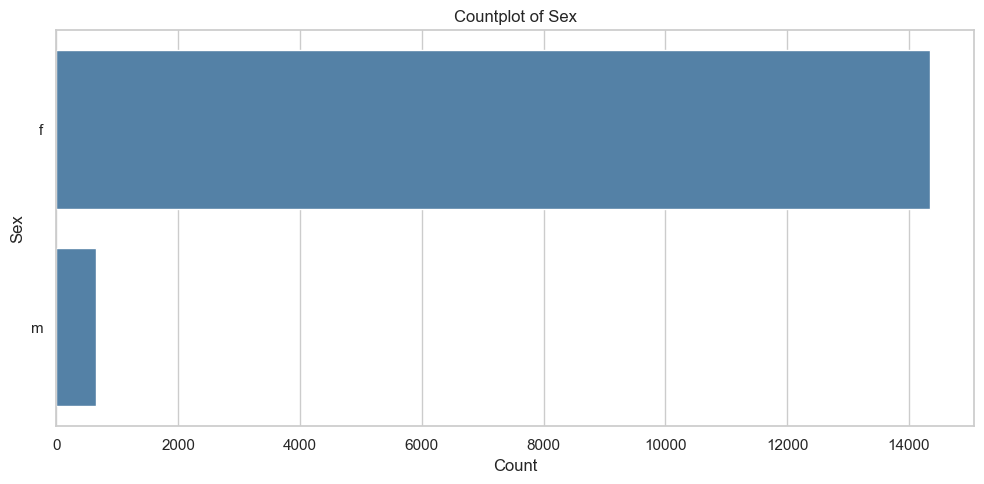


Categorical Feature: Ascites

Frequency Table:
  Ascites  count  percentage
0       n   8062   53.746667
1     NaN   6565   43.766667
2       y    372    2.480000
3       f      1    0.006667


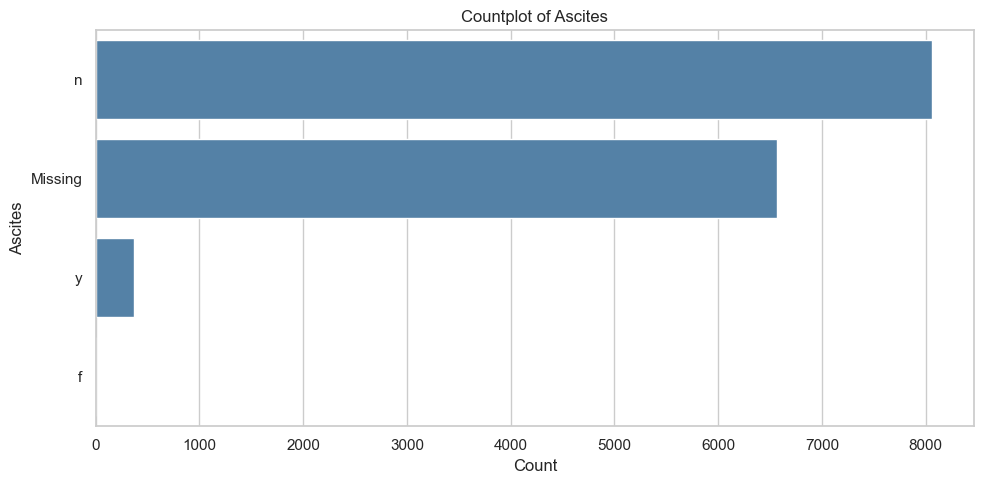


Categorical Feature: Hepatomegaly

Frequency Table:
  Hepatomegaly  count  percentage
0          NaN   6585   43.900000
1            n   4510   30.066667
2            y   3905   26.033333


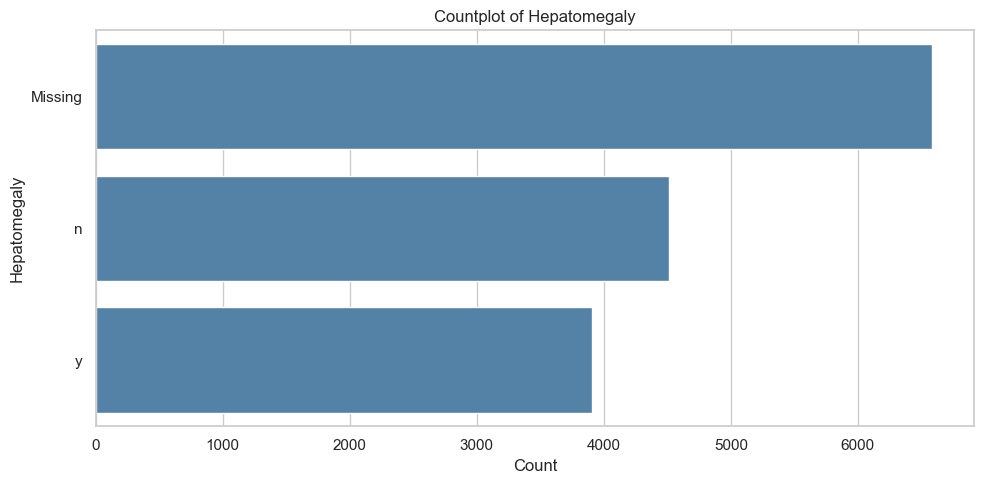


Categorical Feature: Spiders

Frequency Table:
  Spiders  count  percentage
0       n   6675   44.500000
1     NaN   6592   43.946667
2       y   1733   11.553333


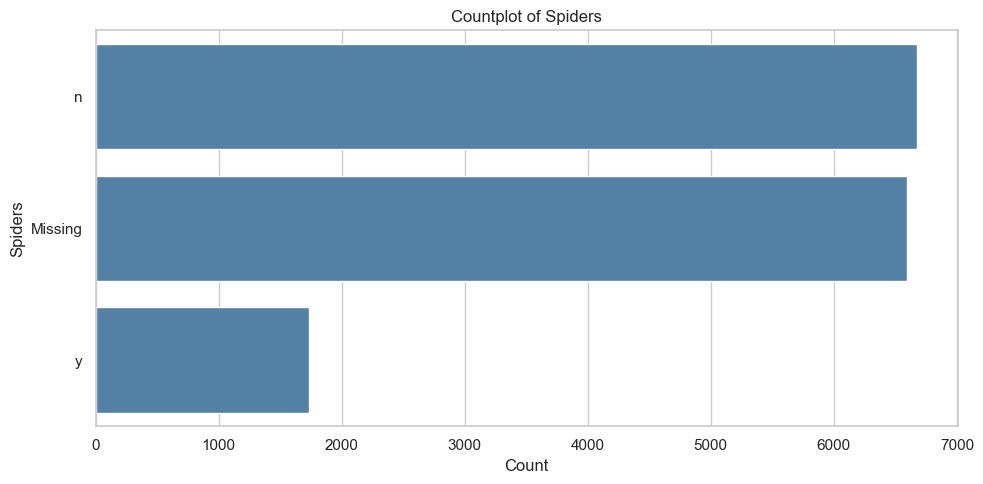


Categorical Feature: Edema

Frequency Table:
  Edema  count  percentage
0     n  13887   92.580000
1     s    764    5.093333
2     y    349    2.326667


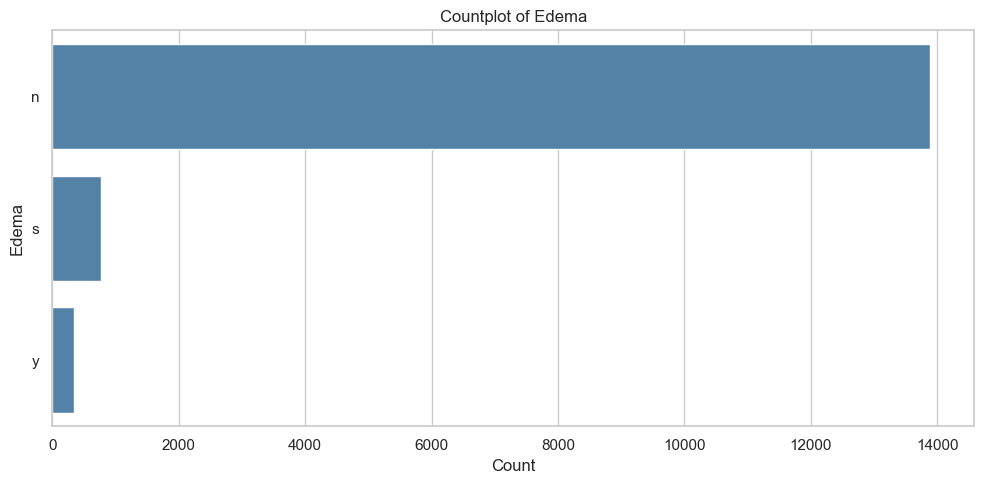

In [22]:
# Set plot style
sns.set(style="whitegrid")

# Loop through each categorical column
for col in cat_cols:
    print("\n==============================")
    print(f"Categorical Feature: {col}")
    print("==============================\n")

    # Frequency table including missing values
    freq_table = df[col].value_counts(dropna=False).reset_index()
    freq_table.columns = [col, "count"]
    freq_table["percentage"] = (freq_table["count"] / len(df)) * 100

    print("Frequency Table:")
    print(freq_table)

    # For plotting, replace missing values only in temporary plot data
    plot_data = df.copy()
    plot_data[col] = plot_data[col].astype("object").fillna("Missing")

    order = plot_data[col].value_counts().index

    plt.figure(figsize=(10, 5))
    sns.countplot(data=plot_data, y=col, order=order, color="steelblue")
    plt.title(f"Countplot of {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

#### Univariate Analysis Insights (Categorical Variables)

##### Sex

- The dataset is **highly imbalanced**, with:
  - Female ≈ 95.7%
  - Male ≈ 4.3%
- This indicates a **strong gender skew**, likely due to the nature of the disease or data collection.
- This imbalance may affect model generalization across genders.

---

#####  Ascites

- Majority of patients:
  - n (No) ≈ 53.7%
- However, **missing values (~43.7%) are very high**, nearly equal to observed data.
- Presence of Ascites (y) is very low (~2.5%).
- The high missing proportion suggests potential **data recording issues or selective testing**.

---

#####  Hepatomegaly

- Missing values are again **very high (~44%)**.
- Among observed values:
  - n (No) ≈ 30%
  - y (Yes) ≈ 26%
- The distribution is relatively balanced among recorded entries.
- Missingness may impact the reliability of this feature.

---

##### Spiders

- Distribution is:
  - n (No) ≈ 44.5%
  - y (Yes) ≈ 11.5%
  - Missing ≈ 44%
- Missing values are almost equal to non-missing values.
- Presence of spiders is relatively rare.
- Indicates potential **imbalance + missingness issue**.

---

#####  Edema

- Highly skewed distribution:
  - n (No) ≈ 92.6%
  - s (Slight) ≈ 5.1%
  - y (Yes) ≈ 2.3%
- Majority of patients do not exhibit edema.
- This variable is **highly imbalanced**, which may limit its predictive contribution.

---

##### Overall Observations

- Several categorical variables contain **very high missing values (~40–45%)**, especially:
  - Drug
  - Ascites
  - Hepatomegaly
  - Spiders

- Many variables are **imbalanced**, with one category dominating:
  - Sex (female dominant)
  - Edema (mostly 'n')

- Some medical conditions (Ascites, Spiders) have **low positive cases**, indicating rarity.

---

##### Implications for Modeling

- High missing values require **careful imputation strategies**.
- Imbalanced categories may:
  - reduce predictive power
  - require attention during modeling
- Rare categories should be handled carefully to avoid bias.

---

#####  Conclusion

Categorical variables show:
- high missingness
- class imbalance
- dominance of certain categories

These characteristics must be considered during preprocessing and modeling to ensure reliable predictions.

### 4. Ordinal Variable (Stage)


Ordinal Feature: Stage

Frequency Table:
   Stage  count  percentage
0      1    771    5.140000
1      2   3386   22.573333
2      3   5535   36.900000
3      4   5308   35.386667


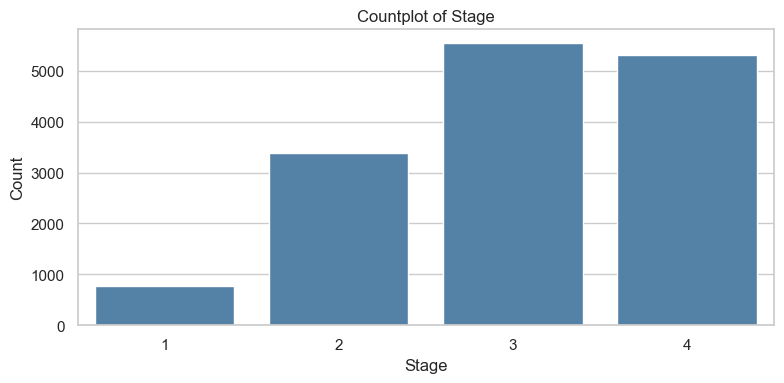

In [23]:
print("\n==============================")
print("Ordinal Feature: Stage")
print("==============================\n")

stage_table = df["Stage"].value_counts(dropna=False).sort_index().reset_index()
stage_table.columns = ["Stage", "count"]
stage_table["percentage"] = (stage_table["count"] / len(df)) * 100

print("Frequency Table:")
print(stage_table)

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="Stage", order=sorted(df["Stage"].dropna().unique()), color="steelblue")
plt.title("Countplot of Stage")
plt.xlabel("Stage")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#### Univariate Analysis Insight (Ordinal Variable: Stage)

#####  Distribution of Stage

- The Stage variable ranges from **1 to 4**, representing increasing levels of disease severity.

- Distribution:
  - Stage 1 ≈ 5.1%
  - Stage 2 ≈ 22.6%
  - Stage 3 ≈ 36.9%
  - Stage 4 ≈ 35.4%

---

##### Key Observations

- The dataset is **heavily concentrated in higher stages (3 and 4)**.
- Early-stage cases (Stage 1) are **very underrepresented**.
- Stage 3 and Stage 4 together account for **over 70% of the data**, indicating that most patients are in **advanced stages of the disease**.

---

##### Implications

- The dataset is **imbalanced across disease stages**, with fewer early-stage observations.
- This may impact the model’s ability to:
  - learn patterns for early-stage conditions
  - generalize across all severity levels

---

##### Modeling Considerations

- Stage should be treated as an **ordinal feature**, not purely categorical, since it has a natural order.
- Its strong concentration in higher stages suggests it may be an **important predictor** for the target variable.

---

##### Conclusion

The Stage variable shows:
- clear ordinal structure  
- imbalance toward advanced disease stages  
- potential importance in predicting outcomes  

It should be retained and carefully handled during modeling.

## 4.2 Bivariate Analysis

### Numerical vs Target

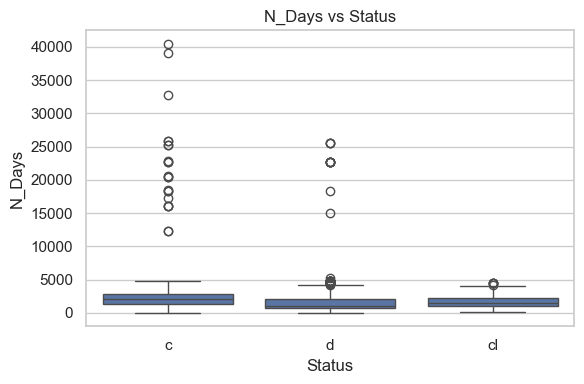

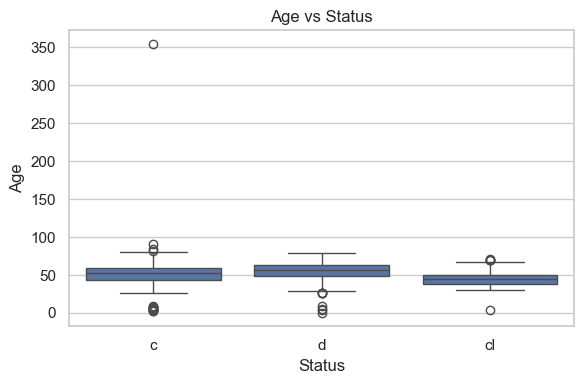

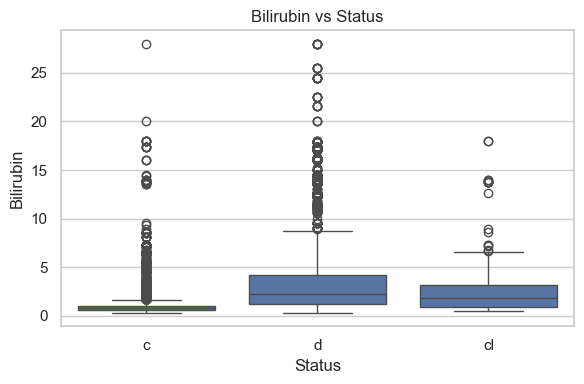

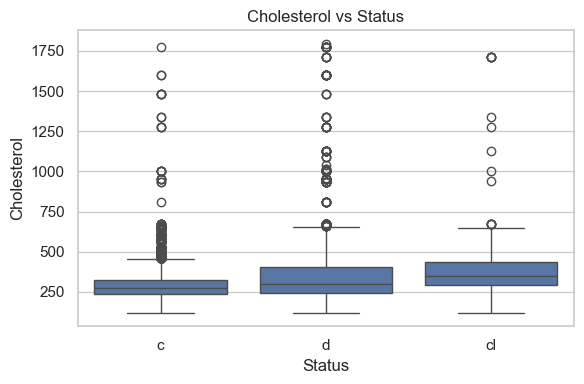

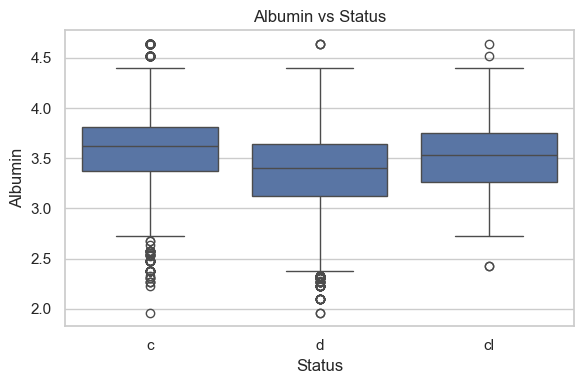

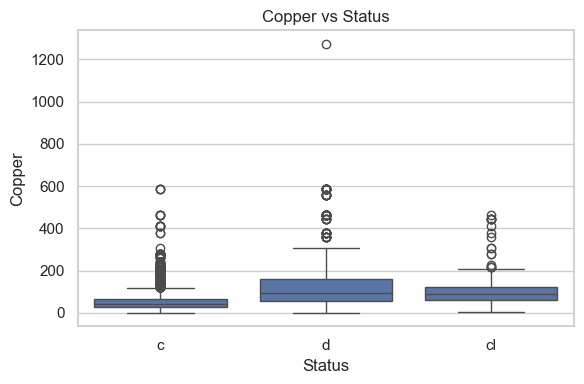

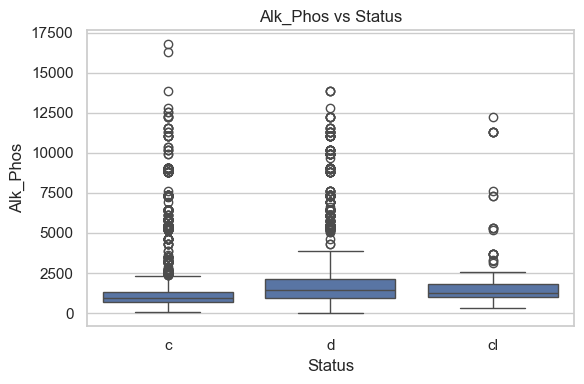

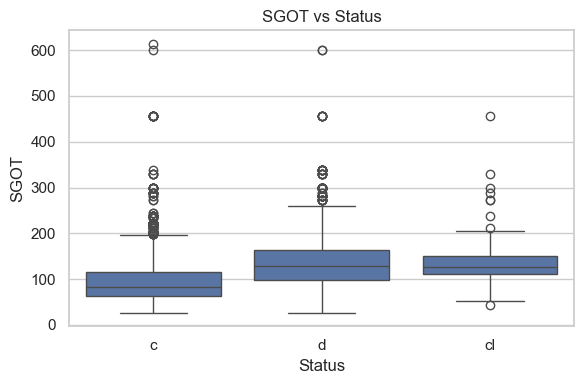

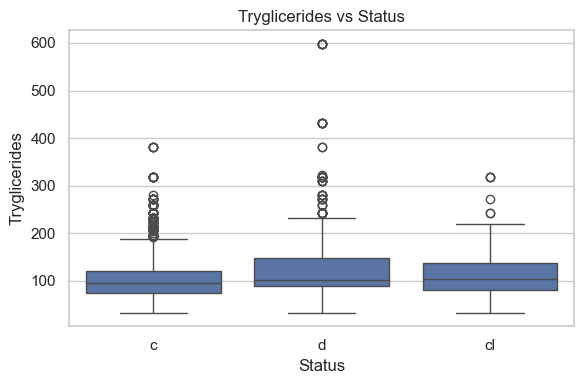

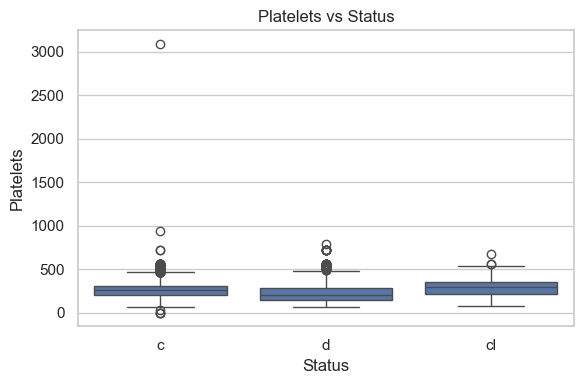

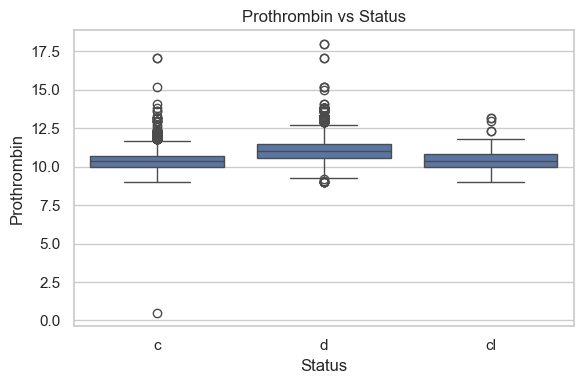

In [24]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=target, y=col, data=df)
    plt.title(f"{col} vs {target}")
    plt.xlabel("Status")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

####  Bivariate Analysis Insights (Numerical Variables vs Status)

##### ⏳ N_Days

- No clear separation between classes.
- All classes show overlapping distributions.
- Presence of extreme outliers in class C.
-  Likely a **weak predictor**.

---

#####  Age

- Distributions across classes are very similar.
- Slight variation but heavy overlap exists.
- Presence of unrealistic outliers still visible.
- Age appears to be a **weak predictor**.

---

##### Bilirubin

- Clear upward trend across classes:
  - C → lowest values
  - CL → moderate
  - D → highest values
- Strong separation in medians and spread.
-  **Strong predictor** of Status.

---

##### Cholesterol

- Slight increase from C → CL → D.
- However, heavy overlap across classes.
- Presence of extreme outliers.
- **Weak to moderate predictor**.

---

##### Albumin

- Clear inverse relationship:
  - C → higher values
  - D → lower values
- Distinct separation in medians.
- **Strong predictor**.

---

##### Copper

- Strong increasing trend:
  - C → low
  - CL → moderate
  - D → high
- Clear separation between classes.
-  **Strong predictor**.

---

##### Alk_Phos

- Increasing trend across classes.
- Higher values associated with worse outcomes.
- Still some overlap but visible shift.
-  **Moderate to strong predictor**.

---

##### SGOT

- Increasing pattern:
  - C → lower
  - D → higher
- Moderate separation between classes.
- **Moderate predictor**.

---

##### Tryglicerides

- Slight increase across classes.
- Heavy overlap between distributions.
-  **Weak to moderate predictor**.

---

##### Platelets

- No consistent pattern across classes.
- Significant overlap.
- Outliers present.
- **Weak predictor**.

---

##### Prothrombin

- Slight increase from C → D.
- Moderate separation in medians.
- Less overlap compared to some features.
-  **Moderate predictor**.

---

##### Overall Conclusion

- Strong predictors:
  - Bilirubin
  - Albumin
  - Copper

- Moderate predictors:
  - Alk_Phos
  - SGOT
  - Prothrombin

- Weak predictors:
  - Age
  - N_Days
  - Platelets
  - Cholesterol
  - Tryglicerides

---

##### Key Observations

- Many variables show **monotonic trends with disease severity**.
- Strong predictors are mostly **biochemical markers**.
- Weak predictors show **high overlap and low class separation**.

---

##### Implications for Modeling

- Strong predictors should be retained and emphasized.
- Weak predictors may:
  - contribute less
  - or be reconsidered during feature selection
- Feature scaling and transformation may improve separation further.

### Categorical vs Target

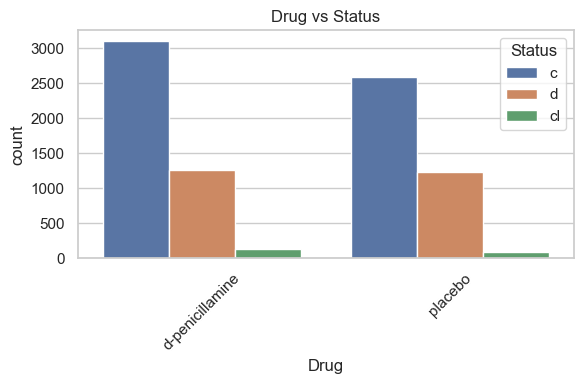

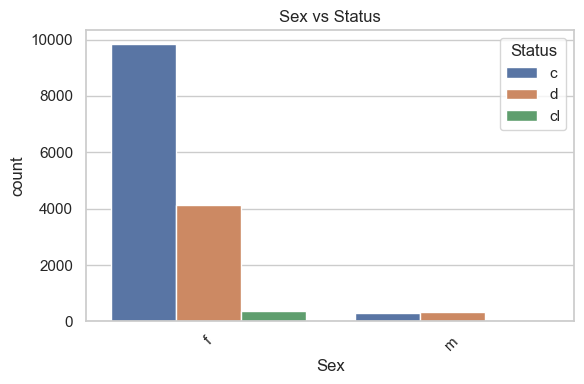

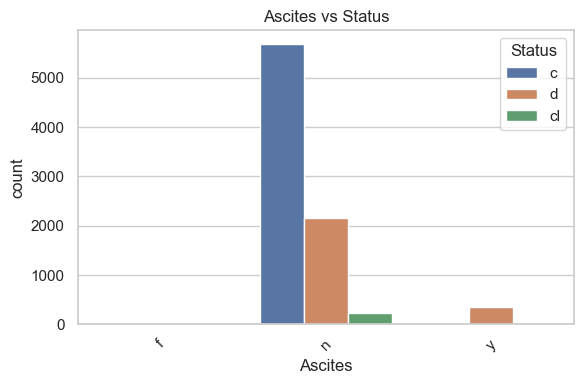

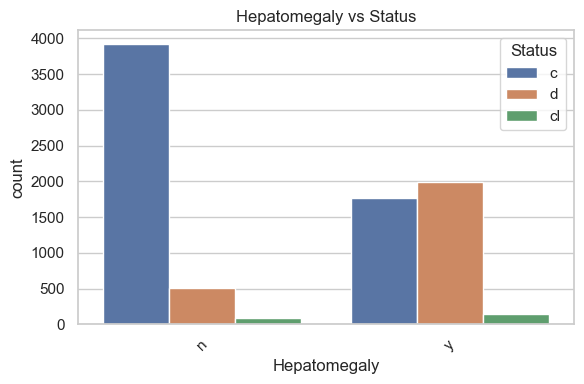

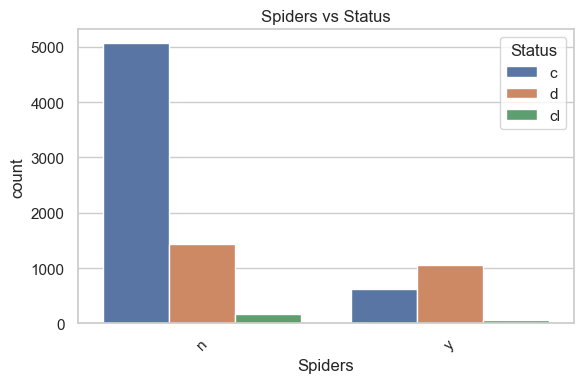

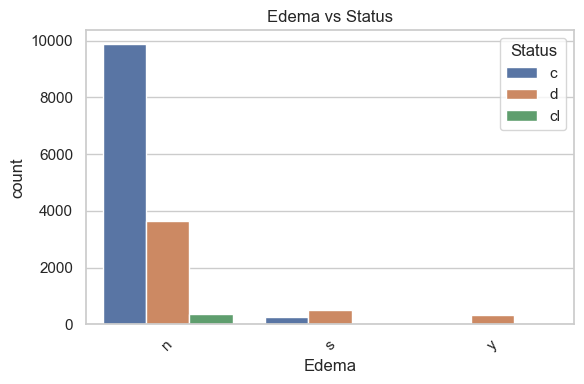

In [25]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue=target, data=df)
    plt.title(f"{col} vs {target}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

####  Bivariate Analysis Insights (Categorical Variables vs Status)

##### Drug

- Both treatment groups (d-penicillamine and placebo) show **very similar distributions across Status classes**.
- No clear dominance of any treatment in a specific outcome category.
- **Weak predictor** — drug type does not strongly differentiate outcomes.

---

##### Sex

- Majority of observations belong to females.
- Both male and female categories show **similar relative distributions across Status**.
- Differences appear due to imbalance, not actual separation.
-  **Weak predictor**.

---

##### Ascites

- Strong pattern observed:
  - Patients with **Ascites = 'y'** are predominantly in worse outcome categories (D).
  - Patients with **Ascites = 'n'** are mostly in class C.
-  **Strong predictor**.

---

##### Hepatomegaly

- Clear shift:
  - Hepatomegaly = 'y' shows higher counts in worse outcomes (D and CL).
  - Hepatomegaly = 'n' shows more concentration in class C.
-  **Moderate to strong predictor**.

---

##### Spiders

- Clear separation:
  - Spiders = 'y' is more associated with worse outcomes (D).
  - Spiders = 'n' is more concentrated in class C.
-  **Strong predictor**.

---

##### Edema

- Very strong pattern:
  - Edema = 'n' → mostly class C
  - Edema = 's' and 'y' → higher proportion of class D
- Clear progression from no edema → severe outcomes.
- **Strong predictor**.

---

##### Overall Conclusion

- Strong categorical predictors:
  - Ascites
  - Spiders
  - Edema

- Moderate predictor:
  - Hepatomegaly

- Weak predictors:
  - Drug
  - Sex

---

##### Key Observations

- Medical condition variables (Ascites, Edema, Spiders) show **clear association with disease severity**.
- Non-clinical variables (Drug, Sex) show **limited predictive power**.
- Strong predictors are aligned with **clinical indicators of liver disease progression**.

---

##### Implications for Modeling

- Strong predictors should be retained as key features.
- Weak predictors may:
  - contribute less to model performance
  - or be evaluated during feature selection.
- Encoding of categorical variables should preserve meaningful distinctions (especially ordinal-like categories such as Edema).

### Ordinal (Stage vs Target)

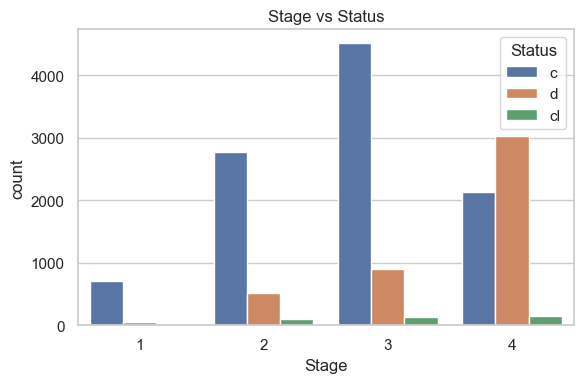

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x="Stage", hue=target, data=df)
plt.title("Stage vs Status")
plt.tight_layout()
plt.show()

## 4.3 Multivariate Analysis

### Correlation Heatmap

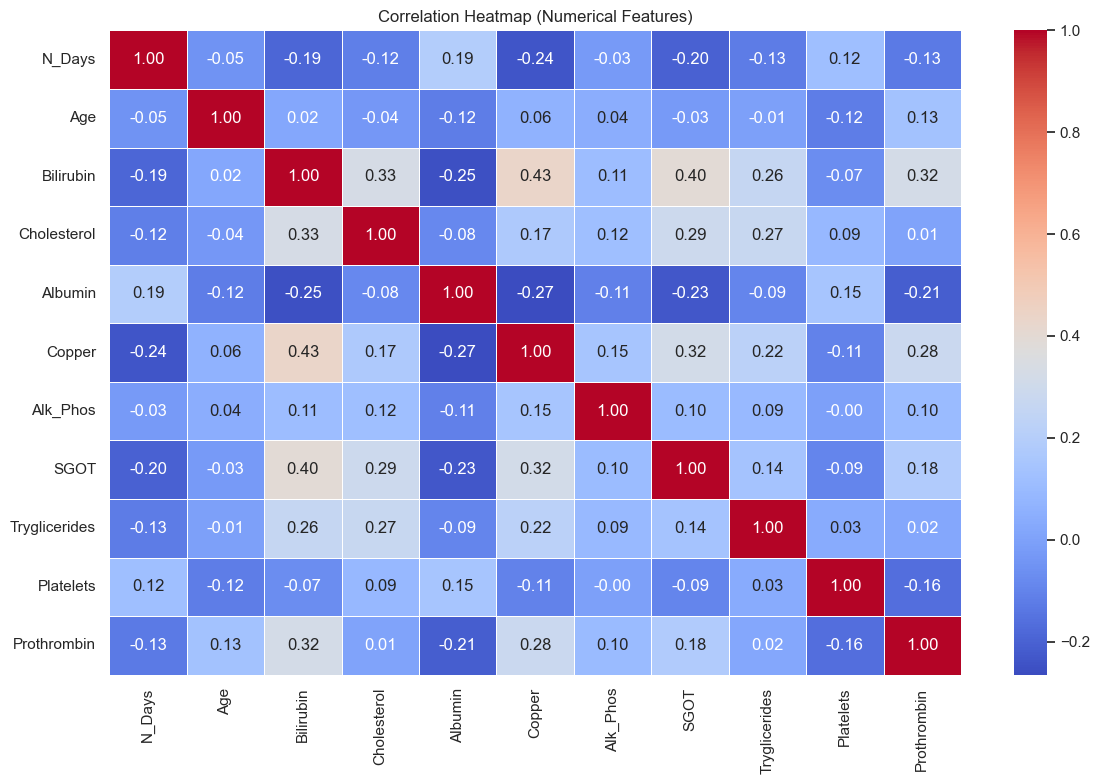

In [27]:
plt.figure(figsize=(12,8))

corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.show()

#### Multicollinearity Check (VIF)

In [28]:
X_vif = df[num_cols].dropna()

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print(vif_data)

          Feature        VIF
0          N_Days   4.257303
1             Age  27.795786
2       Bilirubin   2.324105
3     Cholesterol   5.222730
4         Albumin  75.195508
5          Copper   2.848837
6        Alk_Phos   1.954643
7            SGOT   7.219865
8   Tryglicerides   6.880941
9       Platelets   8.919883
10    Prothrombin  97.229564


#### Combined Insights: Correlation & Multicollinearity

###### Correlation Analysis

- The correlation heatmap shows that most features have **low to moderate correlations**, with no extremely high pairwise correlations (|r| > 0.7).
- Moderate positive relationships are observed among biochemical variables such as:
  - Bilirubin, Copper, SGOT, and Cholesterol
- Negative correlations are observed between:
  - Albumin and several liver-related markers (Bilirubin, Copper, SGOT)

 This reflects expected **biological relationships**, where:
- disease severity markers increase together
- protective markers (Albumin) decrease

---

##### Multicollinearity (VIF Analysis)

- Despite moderate pairwise correlations, VIF results reveal **high multicollinearity** in some variables:
  - Prothrombin (~97)
  - Albumin (~75)
  - Age (~28)

- This indicates that:
  - multicollinearity is driven by **combined linear relationships**, not just pairwise correlations
  - multiple variables jointly explain similar variance in the dataset

---

##### Key Interpretation

- The dataset contains **clinically related features** that are naturally interdependent.
- Correlation analysis suggests **no direct redundancy**, but VIF highlights **hidden multicollinearity** due to multiple interacting variables.

---

##### Decision & Justification

- No features are removed despite high VIF because:
  - They are **clinically meaningful**
  - They showed **strong predictive power in bivariate analysis**
  - Removing them may result in **loss of important information**

---

##### Modeling Implications

- For **tree-based models (Random Forest, XGBoost)**:
  - Multicollinearity is not a concern → all features can be retained

- For **linear models (Logistic Regression)**:
  - Multicollinearity will be handled using **regularization (L2 penalty)**
  - This avoids instability in coefficients without dropping features

---

##### Final Conclusion

- The dataset shows **moderate correlation and high multicollinearity in selected variables**.
- This is expected in medical data with interrelated biomarkers.
- Multicollinearity will be **managed through modeling techniques rather than feature removal**, ensuring that predictive power is preserved.

### Pairplot - Few Important columns

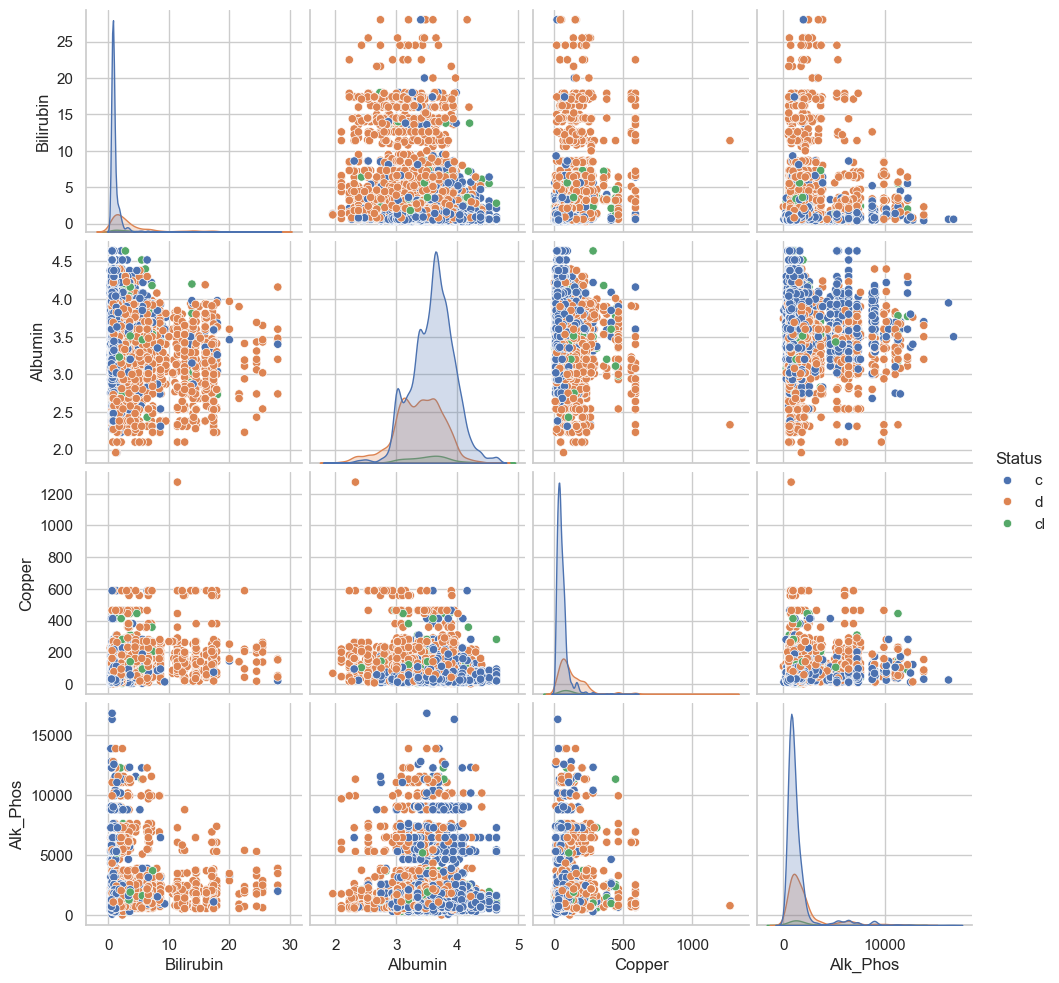

In [29]:
important_cols = ["Bilirubin", "Albumin", "Copper", "Alk_Phos", target]

sns.pairplot(df[important_cols], hue=target)
plt.show()

#### Multivariate Analysis Insights (Pairplot)

##### Overall Observation

- The pairplot shows relationships among key biochemical variables:
  - Bilirubin
  - Albumin
  - Copper
  - Alk_Phos
- Clear clustering patterns are visible across different Status classes.

---

##### Bilirubin Relationships

- Bilirubin shows:
  - **Higher values concentrated in class D**
  - Lower values mostly in class C
- Clear upward spread for severe cases
-  Strong indicator of disease severity

---

##### Albumin Relationships

- Albumin shows an **inverse pattern**:
  - Higher values → mostly class C
  - Lower values → more class D
- This confirms Albumin as a **protective indicator**
-  Strong negative relationship with severity

---

##### Copper Relationships

- Copper values increase with severity:
  - Low values → class C
  - High values → class D
- Moderate clustering observed
- Strong predictor

---

##### Alk_Phos Relationships

- Highly dispersed with extreme values
- Slight upward trend with severity but less clear separation
- Significant overlap between classes
-  Moderate predictor

---

##### Feature Interactions

- **Bilirubin vs Copper**:
  - Positive relationship
  - High values often associated with class D

- **Albumin vs Bilirubin / Copper**:
  - Clear negative relationship
  - As disease markers increase → Albumin decreases

- These relationships confirm **biological consistency of the dataset**

---

##### Class Separation

- Class C:
  - Concentrated in lower Bilirubin, Copper
  - Higher Albumin

- Class D:
  - Spread across higher Bilirubin, Copper
  - Lower Albumin

- Class CL:
  - Scattered between C and D
  - No strong cluster (consistent with imbalance)

---

##### Key Insight

- Disease progression follows a **clear biochemical pattern**:
  - Harmful markers ↑ (Bilirubin, Copper)
  - Protective markers ↓ (Albumin)

- Multiple features together provide **better separation than individual features**

---

##### Conclusion

- Strong multivariate relationships exist among key biochemical variables.
- These variables collectively explain disease severity effectively.
- No single feature fully separates classes, but **combined interaction improves predictability**.

## Final EDA Summary

- Dataset shows strong dependence on biochemical markers
- Stage is the most important predictor
- Clinical variables dominate over demographic variables
- Significant class imbalance present
- Multicollinearity exists but is manageable

These insights guide feature selection and modeling strategy.

### Key Predictors Identified

Strong:
- Stage
- Bilirubin
- Albumin
- Copper

Moderate:
- Alk_Phos
- SGOT
- Prothrombin

Weak:
- Age
- N_Days
- Platelets
- Cholesterol
- Tryglicerides
- Drug
- Sex

In [30]:
# To keep the data safe 
df_clean = df.copy()

# Step 5 : Outlier Detection and Treatment

In [31]:
def detect_outliers_iqr(df):
    """
    Detects outliers in all numeric columns of the DataFrame using the IQR method.
    
    Returns:
        DataFrame with:
        ['column', 'total_count', 'outlier_count', 'outlier_%',
         'lower_bound', 'upper_bound', 'outliers']
    """
    numeric_cols = df.select_dtypes(include=['number']).columns
    outlier_summary = []
    
    for col in numeric_cols:
        # Drop NA for accurate calculation
        data = df[col].dropna()
        
        # Calculate Q1, Q3, IQR
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        
        # Define bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Find outliers
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        
        total_count = data.shape[0]
        outlier_count = outliers.shape[0]
        outlier_percent = (outlier_count / total_count) * 100
        
        outlier_summary.append({
            'column': col,
            'total_count': total_count,
            'outlier_count': outlier_count,
            'outlier_%': round(outlier_percent, 2),
            'lower_bound': round(lower_bound, 2),
            'upper_bound': round(upper_bound, 2),
            'outliers': outliers.values.tolist()
        })
    
    return pd.DataFrame(outlier_summary).sort_values(by="outlier_%", ascending=False)

In [32]:
outlier_df = detect_outliers_iqr(df)
outlier_df
#print(outlier_df[["column", "total_count", "outlier_count", "outlier_%"]])

,column,total_count,outlier_count,outlier_%,lower_bound,upper_bound,outliers
2,Bilirubin,15000,1596,10.64,-0.95,3.45,"[8.6, 4.0, 8.1, 7.1, 8.7, 3.5, 4.5, 3.5, 6.3, 6.6, 7.1, 4.4, 4.6, 9.5, 5.1, 5.4, 14.0, 17.4, 6.5, 9.5, 4.4, 13.6, 4.5, 3.6, 13.8, 3.6, 8.4, 6.8, 7.2, 3.6, 3.6, 4.2, 4.4, 5.5, 4.7, 4.4, 16.0, 6.6, 14.4, 17.4, 4.5, 12.6, 3.5, 8.6, 6.6, 14.0, 5.0, 11.1, 7.1, 12.2, 8.6, 6.6, 14.5, 4.4, 4.7, 3.7, 4.6, 4.2, 3.8, 16.0, 16.2, 5.5, 13.6, 4.4, 18.0, 13.6, 7.3, 6.4, 12.2, 4.6, 5.6, 3.6, 9.0, 8.6, 8.5, 4.4, 11.0, 28.0, 16.0, 4.2, 11.8, 6.1, 3.9, 3.5, 4.0, 7.1, 3.8, 3.6, 7.2, 14.0, 6.6, 3.5, 6.6, 11.4, 3.6, 7.1, 6.4, 14.0, 15.0, 4.4, ...]"
6,Alk_Phos,8405,789,9.39,-701.00,3083.00,"[3896.0, 5300.0, 6456.2, 6456.2, 3228.0, 5396.0, 7277.0, 3681.0, 7277.0, 12557.0, 6456.2, 6931.2, 3292.0, 6931.2, 9066.8, 9066.8, 6456.2, 7277.0, 7394.8, 6456.2, 6121.8, 7394.8, 5833.0, 5396.0, 7394.8, 4651.2, 6456.2, 4332.0, 6064.8, 3186.0, 6456.2, 9066.8, 6121.8, 5487.2, 7277.0, 9066.8, 3472.0, 6456.2, 16300.0, 9066.8, 7277.0, 6121.8, 9933.2, 7224.0, 5487.2, 6456.2, 5890.0, 7277.0, 3697.4, 5833.0, 11046.6, 11046.6, 5300.0, 6456.2, 4651.2, 9066.8, 3228.0, 8778.0, 6456.2, 7394.8, 3336.0, 8778.0, 11552.0, 3472.0, 5300.0, 9009.8, 6456.2, 6456.2, 7300.0, 6456.2, 5833.0, 6456.2, 6456.2, 7277.0, 7394.8, 6121.8, 3228.0, 9933.2, 6456.2, 5719.0, 8778.0, 8778.0, 5487.2, 5487.2, 5487.2, 5487.2, 8778.0, 6456.2, 4651.2, 6456.2, 9066.8, 3836.0, 6456.2, 6456.2, 7277.0, 12784.8, 6456.2, 4651.2, 4332.0, 11046.6, ...]"
5,Copper,8295,687,8.28,-52.00,172.00,"[199.0, 205.0, 227.0, 178.0, 290.0, 234.0, 200.0, 588.0, 281.0, 209.0, 262.0, 267.0, 380.0, 444.0, 196.0, 464.0, 217.0, 234.0, 464.0, 219.0, 233.0, 227.0, 182.0, 225.0, 177.0, 225.0, 234.0, 173.0, 234.0, 412.0, 182.0, 254.0, 588.0, 588.0, 210.0, 380.0, 281.0, 280.0, 201.0, 196.0, 234.0, 464.0, 221.0, 208.0, 269.0, 208.0, 221.0, 231.0, 205.0, 220.0, 200.0, 221.0, 201.0, 233.0, 234.0, 178.0, 220.0, 281.0, 205.0, 281.0, 231.0, 227.0, 205.0, 221.0, 182.0, 251.0, 231.0, 178.0, 247.0, 208.0, 464.0, 227.0, 201.0, 464.0, 464.0, 244.0, 267.0, 182.0, 380.0, 464.0, 233.0, 182.0, 234.0, 196.0, 262.0, 281.0, 178.0, 231.0, 208.0, 412.0, 412.0, 219.0, 196.0, 262.0, 234.0, 268.0, 247.0, 308.0, 177.0, 269.0, ...]"
3,Cholesterol,6629,450,6.79,72.50,516.50,"[578.0, 528.0, 1000.0, 674.0, 1000.0, 608.0, 674.0, 674.0, 1336.0, 674.0, 674.0, 652.0, 556.0, 578.0, 528.0, 674.0, 562.0, 556.0, 578.0, 604.0, 646.0, 674.0, 528.0, 808.0, 1775.0, 1128.0, 1000.0, 572.0, 932.0, 608.0, 652.0, 674.0, 1015.0, 960.0, 604.0, 1600.0, 1128.0, 652.0, 586.0, 586.0, 1336.0, 652.0, 518.0, 950.0, 932.0, 604.0, 604.0, 932.0, 1600.0, 576.0, 652.0, 558.0, 674.0, 604.0, 572.0, 674.0, 652.0, 1000.0, 808.0, 578.0, 578.0, 674.0, 528.0, 808.0, 518.0, 932.0, 660.0, 1128.0, 1600.0, 645.0, 1276.0, 1128.0, 572.0, 1000.0, 636.0, 674.0, 674.0, 518.0, 674.0, 578.0, 660.0, 604.0, 674.0, 1600.0, 950.0, 660.0, 808.0, 562.0, 808.0, 518.0, 546.0, 1480.0, 578.0, 562.0, 674.0, 1276.0, 1480.0, 578.0, 674.0, 636.0, ...]"
8,Tryglicerides,6583,260,3.95,0.50,212.50,"[214.0, 232.0, 214.0, 214.0, 319.0, 242.0, 231.0, 230.0, 272.0, 242.0, 231.0, 242.0, 272.0, 280.0, 214.0, 242.0, 280.0, 272.0, 214.0, 382.0, 232.0, 232.0, 232.0, 213.0, 229.0, 232.0, 219.0, 219.0, 218.0, 598.0, 242.0, 232.0, 319.0, 213.0, 260.0, 214.0, 218.0, 322.0, 213.0, 224.0, 260.0, 232.0, 382.0, 242.0, 214.0, 382.0, 598.0, 382.0, 224.0, 318.0, 232.0, 260.0, 229.0, 224.0, 319.0, 214.0, 232.0, 319.0, 260.0, 260.0, 213.0, 260.0, 229.0, 219.0, 214.0, 231.0, 260.0, 213.0, 219.0, 214.0, 214.0, 231.0, 280.0, 319.0, 280.0, 598.0, 231.0, 309.0, 224.0, 232.0, 260.0, 213.0, 260.0, 229.0, 272.0, 242.0, 214.0, 319.0, 213.0, 598.0, 309.0, 214.0, 319.0, 260.0, 242.0, 242.0, 260.0, 214.0, 272.0, 232.0, ...]"
10,Prothrombin,14980,373,2.49,8.75,12.35,"[13.6, 12.4, 13.6, 12.6, 13.8, 12.4, 15.2, 13.2, 13.2, 12.9, 13.6, 12.9, 17.1, 12.4, 12.4, 13.3, 13.8, 12.7, 12.7, 12.4, 12.6, 13.0, 13.2, 12.4, 13.0, 13.0, 13.1, 12.9, 13.0, 13.6, 13.2,

## Removing Unrealistic Age Rows

In [33]:
# Remove unrealistic age rows
df = df[df["Age"] <= 100]

## Outlier Handling Strategy

Outlier treatment was performed carefully considering the nature of medical data.

- Extreme values were not removed if they were clinically meaningful, as they may represent severe disease cases.

- However, clearly unrealistic values were identified and removed:
  - For example, Age values exceeding 100 were treated as data entry errors and excluded.

- Instead of aggressive outlier removal or capping, skewed variables will be transformed (e.g., log transformation) in the feature engineering stage.
- columns that we should log transform : "Bilirubin", "Copper", "Alk_Phos", "SGOT", "Tryglicerides"
### Justification

- Preserves clinically important extreme values
- Removes only erroneous observations
- Ensures model stability without losing meaningful information

In [34]:
df.head()

,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
0,994.0,d-penicillamine,40.928767,f,n,n,n,n,0.9,227.0,3.02,40.0,663.0,93.0,69.0,244.0,9.9,2,c
1,2267.0,NaN,55.038356,f,NaN,NaN,NaN,n,0.7,NaN,3.29,NaN,NaN,NaN,NaN,209.0,10.3,3,c
2,4062.0,NaN,64.043836,f,NaN,NaN,NaN,n,0.8,NaN,3.01,NaN,NaN,NaN,NaN,388.0,11.1,4,c
3,1216.0,placebo,56.117808,f,n,n,n,n,0.6,248.0,3.35,44.0,1072.0,55.8,108.0,493.0,10.5,3,c
4,2555.0,NaN,61.041096,f,NaN,NaN,NaN,n,1.1,NaN,3.64,NaN,NaN,NaN,NaN,109.0,10.5,1,c


In [35]:
df.to_csv("E:/Cranfield_BDA/AIML/assignment/cirrhosis-outcomes-challenge-a-multi-class-prediction-task/after_cleaning_eda/training_Set_after_EDA_cleaning.csv", index = False)

# Step 6 : Spliting the data into train test and Validation (80-10-10)

In [36]:
# =========================================================
# MISSING VALUE IMPUTATION BASED ON ACTUAL MISSING SUMMARY
# =========================================================

# ---------------------------------------------------------
# 1. Target and column groups
# ---------------------------------------------------------
target = "Status"

# Numerical columns with very high missingness
high_missing_num_cols = [
    "Tryglicerides",
    "Cholesterol",
    "Copper",
    "Alk_Phos",
    "SGOT"
]

# Numerical columns with low missingness
low_missing_num_cols = [
    "Platelets",
    "Prothrombin"
]

# Numerical columns with no missing values
no_missing_num_cols = [
    "N_Days",
    "Age",
    "Bilirubin",
    "Albumin"
]

# Categorical columns with high missingness
high_missing_cat_cols = [
    "Spiders",
    "Drug",
    "Hepatomegaly",
    "Ascites"
]

# Categorical columns with no missing values
no_missing_cat_cols = [
    "Sex",
    "Edema"
]

# Ordinal columns
ordinal_cols = ["Stage"]
# =========================================================
# FIX: MAP TARGET VARIABLE (ONLY IF STILL TEXT)
# =========================================================

df["Status"] = df["Status"].astype(str).str.strip().str.lower()

target_map = {"c": 0, "cl": 1, "d": 2}
df["Status"] = df["Status"].map(target_map)

print(df["Status"].value_counts())
# ---------------------------------------------------------
# 2. Split X and y
# ---------------------------------------------------------
X = df.drop(columns=[target]).copy()
y = df[target].copy()

# Drop ID if present
if "id" in X.columns:
    X = X.drop(columns=["id"])

# ---------------------------------------------------------
# 3. Train / Validation / Test split
# ---------------------------------------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

Status
0    10116
2     4489
1      394
Name: count, dtype: int64


# Step 7 : Feature Engineering

### Missing Values Imputation and Log Transformation

In [37]:
# ---------------------------------------------------------
# 4. Check missing values before imputation
# ---------------------------------------------------------
print("Missing values in X_train BEFORE imputation:\n")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0].sort_values(ascending=False))

# ---------------------------------------------------------
# 5. Create missing indicators for high-missing numeric columns
# ---------------------------------------------------------
for col in high_missing_num_cols:
    X_train[col + "_missing"] = X_train[col].isna().astype(int)
    X_val[col + "_missing"] = X_val[col].isna().astype(int)
    X_test[col + "_missing"] = X_test[col].isna().astype(int)

# ---------------------------------------------------------
# 6. Median imputation for low-missing numeric columns
# ---------------------------------------------------------
median_imputer = SimpleImputer(strategy="median")

X_train[low_missing_num_cols] = median_imputer.fit_transform(X_train[low_missing_num_cols])
X_val[low_missing_num_cols] = median_imputer.transform(X_val[low_missing_num_cols])
X_test[low_missing_num_cols] = median_imputer.transform(X_test[low_missing_num_cols])

# ---------------------------------------------------------
# 7. Iterative imputation for high-missing numeric columns
# ---------------------------------------------------------
iter_imputer = IterativeImputer(
    random_state=42,
    max_iter=20,
    initial_strategy="median"
)

X_train[high_missing_num_cols] = iter_imputer.fit_transform(X_train[high_missing_num_cols])
X_val[high_missing_num_cols] = iter_imputer.transform(X_val[high_missing_num_cols])
X_test[high_missing_num_cols] = iter_imputer.transform(X_test[high_missing_num_cols])

# ---------------------------------------------------------
# 8. Fill high-missing categorical columns with "No Data"
# ---------------------------------------------------------
for col in high_missing_cat_cols:
    X_train[col] = X_train[col].astype("object").fillna("No Data")
    X_val[col] = X_val[col].astype("object").fillna("No Data")
    X_test[col] = X_test[col].astype("object").fillna("No Data")

# ---------------------------------------------------------
# 9. Convert all categorical columns to category dtype
# ---------------------------------------------------------
all_cat_cols = high_missing_cat_cols + no_missing_cat_cols

for col in all_cat_cols:
    X_train[col] = X_train[col].astype("category")
    X_val[col] = X_val[col].astype("category")
    X_test[col] = X_test[col].astype("category")

# ---------------------------------------------------------
# 10. Impute ordinal column if needed
# ---------------------------------------------------------
if X_train[ordinal_cols].isnull().sum().sum() > 0:
    stage_imputer = SimpleImputer(strategy="most_frequent")
    X_train[ordinal_cols] = stage_imputer.fit_transform(X_train[ordinal_cols])
    X_val[ordinal_cols] = stage_imputer.transform(X_val[ordinal_cols])
    X_test[ordinal_cols] = stage_imputer.transform(X_test[ordinal_cols])

# ---------------------------------------------------------
# 11. Final missing-value check
# ---------------------------------------------------------
print("\nMissing values in X_train AFTER imputation:", X_train.isnull().sum().sum())
print("Missing values in X_val AFTER imputation:", X_val.isnull().sum().sum())
print("Missing values in X_test AFTER imputation:", X_test.isnull().sum().sum())

# =========================================================
# Log Transformation After Imputation
# =========================================================

log_name_map = {
    "Bilirubin": "bilirubin_log",
    "Cholesterol": "cholesterol_log",
    "Copper": "copper_log",
    "Alk_Phos": "alk_phos_log",
    "SGOT": "sgot_log",
    "Tryglicerides": "tryglicerides_log"
}

for original_col, new_col in log_name_map.items():
    X_train[new_col] = np.log1p(X_train[original_col].clip(lower=0))
    X_val[new_col] = np.log1p(X_val[original_col].clip(lower=0))
    X_test[new_col] = np.log1p(X_test[original_col].clip(lower=0))

# ---------------------------------------------------------
# 12. Final feature groups for later preprocessing
# ---------------------------------------------------------
missing_flag_cols = [col + "_missing" for col in high_missing_num_cols]

final_num_cols = no_missing_num_cols + low_missing_num_cols + high_missing_num_cols + missing_flag_cols
final_cat_cols = all_cat_cols
final_ordinal_cols = ordinal_cols

print("\nFinal numeric columns:")
print(final_num_cols)

print("\nFinal categorical columns:")
print(final_cat_cols)

print("\nFinal ordinal columns:")
print(final_ordinal_cols)

# ---------------------------------------------------------
# 13. Final shape check
# ---------------------------------------------------------
print("\nX_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_val shape  :", y_val.shape)
print("y_test shape :", y_test.shape)

Missing values in X_train BEFORE imputation:

Tryglicerides    6729
Cholesterol      6687
Copper           5348
Alk_Phos         5262
Spiders          5260
SGOT             5260
Drug             5258
Hepatomegaly     5255
Ascites          5238
Platelets         493
Prothrombin        17
dtype: int64

Missing values in X_train AFTER imputation: 0
Missing values in X_val AFTER imputation: 0
Missing values in X_test AFTER imputation: 0

Final numeric columns:
['N_Days', 'Age', 'Bilirubin', 'Albumin', 'Platelets', 'Prothrombin', 'Tryglicerides', 'Cholesterol', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides_missing', 'Cholesterol_missing', 'Copper_missing', 'Alk_Phos_missing', 'SGOT_missing']

Final categorical columns:
['Spiders', 'Drug', 'Hepatomegaly', 'Ascites', 'Sex', 'Edema']

Final ordinal columns:
['Stage']

X_train shape: (11999, 29)
X_val shape  : (1500, 29)
X_test shape : (1500, 29)

y_train shape: (11999,)
y_val shape  : (1500,)
y_test shape : (1500,)


## Missing Value Imputation Insights

- The dataset contained a substantial number of missing values, particularly in several laboratory and clinical variables such as Tryglicerides, Cholesterol, Copper, Alk_Phos, SGOT, Spiders, Drug, Hepatomegaly, and Ascites.
- Missing values were handled after splitting the data into training, validation, and test sets to avoid data leakage.
- Numerical variables with relatively low missingness, such as Platelets and Prothrombin, were imputed using the median because the median is robust to skewness and extreme values.
- Numerical variables with high missingness, such as Cholesterol, Copper, Alk_Phos, SGOT, and Tryglicerides, were imputed using Iterative Imputation.
- Iterative Imputation was selected because these laboratory variables are clinically related and can be estimated using information from other features in the dataset.
- Categorical variables with missing values, such as Drug, Ascites, Hepatomegaly, Spiders, and Edema, were imputed using the mode or a separate category such as "No Data".
- This approach preserved all observations in the dataset and avoided losing information through row deletion.
- Missing value indicator variables were also created for selected high-missing numerical variables to record which observations originally contained missing values before imputation.
- These indicators were primarily used to improve transparency in preprocessing and to monitor where imputation had been applied.
- Overall, the chosen imputation strategy balanced simplicity, clinical relevance, and preservation of the original dataset structure.

## Log Transformation Insights

- Several numerical variables showed strong positive skewness and contained extreme outliers.
- Variables such as Bilirubin, Cholesterol, Copper, Alk_Phos, SGOT, and Tryglicerides had highly skewed distributions.
- A log transformation was applied to these variables using the `log1p()` function.
- The `log1p()` function was used instead of a standard logarithm because some variables contained zero values, and `log1p(x)` safely computes `log(1 + x)`.
- Log transformation helps reduce the impact of extreme values and compresses the scale of highly skewed variables.
- This makes the distributions more balanced and improves model stability.
- Log transformation is particularly useful for medical laboratory variables because many biological measurements tend to have long right tails.
- By reducing skewness, the transformed variables become more suitable for machine learning models, especially for models such as Logistic Regression and Neural Networks that are sensitive to feature distribution.
- The transformed variables were added as new features while the original highly skewed variables were removed from the final modelling dataset.
- Overall, log transformation improved the quality of the input features and reduced the influence of extreme observations.

# Step 8 : Model Preprocessing

In [38]:

# =========================================================
# FINAL FEATURE LIST
# =========================================================
final_num_cols = [
    'N_Days',
    'Age',
    'bilirubin_log',
    'cholesterol_log',
    'Albumin',
    'copper_log',
    'alk_phos_log',
    'sgot_log',
    'tryglicerides_log',
    'Platelets',
    'Prothrombin',
    'Stage'
]

final_cat_cols = [
    'Drug',
    'Sex',
    'Ascites',
    'Hepatomegaly',
    'Spiders',
    'Edema'
]

target = 'Status'   # change if needed

# =========================================================
# =========================================================
# PREPROCESSORS
# =========================================================
# Scaled preprocessor: for Logistic Regression and Neural Network
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), final_num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), final_cat_cols)
    ]
)

# Unscaled preprocessor: for Random Forest and XGBoost
preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', final_num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), final_cat_cols)
    ]
)

# If sparse_output=False gives error, use sparse=False

## Stage Variable Treatment

- The `Stage` variable is ordinal in nature because higher stages represent more severe disease progression.
- In the final modelling pipeline, `Stage` was retained as a numeric ordered predictor rather than being one-hot encoded.
- This approach preserves the natural ordering of disease severity and allows the models to learn the relationship between increasing stage and worsening patient outcomes.

# Step 9 : Model Building 

In [39]:
# =========================================================
# LOGISTIC REGRESSION MODEL
# =========================================================
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor_scaled),
    ('clf', LogisticRegression(
        penalty='l2',
        max_iter=2000,
        solver='liblinear',
        class_weight='balanced',
        random_state=42
    ))
])

log_model.fit(X_train, y_train)



,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [40]:
# =========================================================
# RANDOM FOREST MODEL
# =========================================================
rf_model = ImbPipeline(steps=[
    ('preprocessor', preprocessor_unscaled),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)



,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [41]:
# =========================================================
# XGBOOST MODEL
# =========================================================
xgb_model = ImbPipeline(steps=[
    ('preprocessor', preprocessor_unscaled),
    ('smote', SMOTE(random_state=42)),
    ('clf', XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [42]:
# =========================================================
# NEURAL NETWORK MODEL
# =========================================================
nn_model = ImbPipeline(steps=[
    ('preprocessor', preprocessor_scaled),
    ('smote', SMOTE(random_state=42)),
    ('clf', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        random_state=42
    ))
])

nn_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Step 10 : Model Evaluation and Comparison

Logistic Regression
Train Accuracy: 0.8239853321110092
Evaluation Accuracy: 0.8253333333333334
Precision (Macro): 0.6375753083816664
Recall (Macro): 0.6362791035799964
F1 Score (Macro): 0.6365249084996636
ROC-AUC (Macro, OVR): 0.8758739056910668

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.90      0.89      1011
           1       0.28      0.30      0.29        40
           2       0.76      0.71      0.73       449

    accuracy                           0.83      1500
   macro avg       0.64      0.64      0.64      1500
weighted avg       0.82      0.83      0.82      1500


Confusion Matrix:

[[906  15  90]
 [ 16  12  12]
 [113  16 320]]


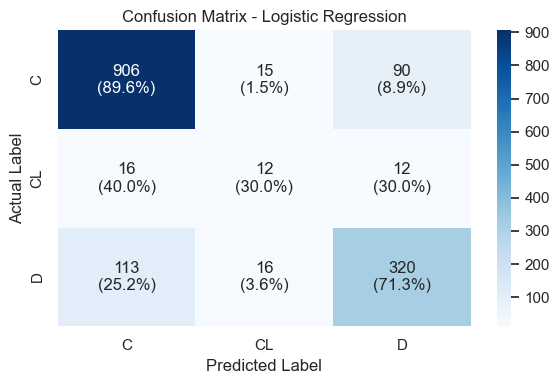

Random Forest
Train Accuracy: 0.9603300275022919
Evaluation Accuracy: 0.8493333333333334
Precision (Macro): 0.70458849861206
Recall (Macro): 0.6248003953541482
F1 Score (Macro): 0.6490543172593964
ROC-AUC (Macro, OVR): 0.9241481790551843

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.91      0.90      1011
           1       0.44      0.20      0.28        40
           2       0.79      0.76      0.77       449

    accuracy                           0.85      1500
   macro avg       0.70      0.62      0.65      1500
weighted avg       0.84      0.85      0.84      1500


Confusion Matrix:

[[925   8  78]
 [ 18   8  14]
 [106   2 341]]


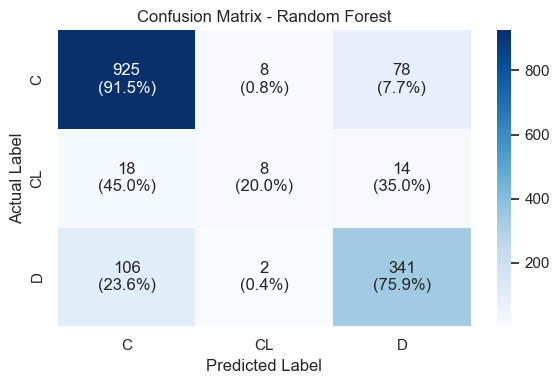

XGBoost
Train Accuracy: 0.8809900825068756
Evaluation Accuracy: 0.844
Precision (Macro): 0.6721975554547838
Recall (Macro): 0.659704773108281
F1 Score (Macro): 0.6656162282945276
ROC-AUC (Macro, OVR): 0.9180448610360408

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.91      0.90      1011
           1       0.34      0.33      0.33        40
           2       0.79      0.75      0.77       449

    accuracy                           0.84      1500
   macro avg       0.67      0.66      0.67      1500
weighted avg       0.84      0.84      0.84      1500


Confusion Matrix:

[[918  14  79]
 [ 17  13  10]
 [103  11 335]]


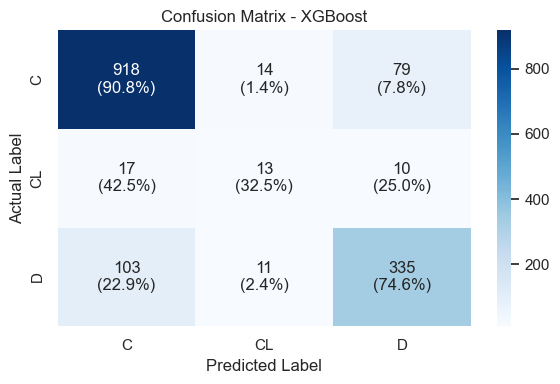

Neural Network
Train Accuracy: 0.8452371030919243
Evaluation Accuracy: 0.792
Precision (Macro): 0.5844897105253147
Recall (Macro): 0.6321742936092001
F1 Score (Macro): 0.6004178156448733
ROC-AUC (Macro, OVR): 0.8656213638887018

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.82      0.86      1011
           1       0.17      0.30      0.21        40
           2       0.69      0.78      0.73       449

    accuracy                           0.79      1500
   macro avg       0.58      0.63      0.60      1500
weighted avg       0.82      0.79      0.80      1500


Confusion Matrix:

[[826  41 144]
 [ 14  12  14]
 [ 80  19 350]]


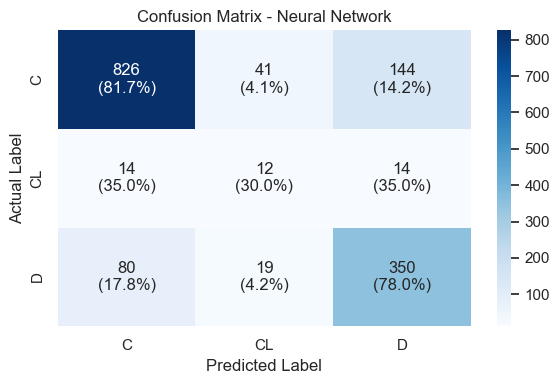


Model Comparison Table:

                 Model  Accuracy  Precision_Macro  Recall_Macro  F1_Macro  \
1        Random Forest  0.849333         0.704588      0.624800  0.649054   
2              XGBoost  0.844000         0.672198      0.659705  0.665616   
0  Logistic Regression  0.825333         0.637575      0.636279  0.636525   
3       Neural Network  0.792000         0.584490      0.632174  0.600418   

   ROC_AUC_Macro_OVR  
1           0.924148  
2           0.918045  
0           0.875874  
3           0.865621  


In [43]:
# =========================================================
# CONFUSION MATRIX PLOT FUNCTION
# =========================================================
def plot_confusion_matrix_with_percentages(y_true, y_pred, model_name, labels):
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm / cm.sum(axis=1, keepdims=True)

    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n({cm_percent[i, j] * 100:.1f}%)"

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=annot,
        fmt='',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.show()

# =========================================================
# MODEL EVALUATION FUNCTION
# =========================================================
def evaluate_model(model, X_train, X_eval, y_train, y_eval, model_name, class_labels):

    y_train_pred = model.predict(X_train)
    y_eval_pred = model.predict(X_eval)
    y_eval_proba = model.predict_proba(X_eval)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
    print("Evaluation Accuracy:", accuracy_score(y_eval, y_eval_pred))
    print("Precision (Macro):", precision_score(y_eval, y_eval_pred, average='macro'))
    print("Recall (Macro):", recall_score(y_eval, y_eval_pred, average='macro'))
    print("F1 Score (Macro):", f1_score(y_eval, y_eval_pred, average='macro'))
    print("ROC-AUC (Macro, OVR):", roc_auc_score(
        y_eval,
        y_eval_proba,
        multi_class='ovr',
        average='macro'
    ))

    print("\nClassification Report:\n")
    print(classification_report(y_eval, y_eval_pred))

    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_eval, y_eval_pred))

    plot_confusion_matrix_with_percentages(
        y_true=y_eval,
        y_pred=y_eval_pred,
        model_name=model_name,
        labels=class_labels
    )


# =========================================================
# EVALUATE ALL MODELS
# =========================================================
class_labels = ["C", "CL", "D"]

evaluate_model(log_model, X_train, X_val, y_train, y_val, 'Logistic Regression', class_labels)
evaluate_model(rf_model, X_train, X_val, y_train, y_val, 'Random Forest', class_labels)
evaluate_model(xgb_model, X_train, X_val, y_train, y_val, 'XGBoost', class_labels)
evaluate_model(nn_model, X_train, X_val, y_train, y_val, 'Neural Network', class_labels)

# =========================================================
# MODEL COMPARISON TABLE
# =========================================================
results = []

models = {
    'Logistic Regression': log_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'Neural Network': nn_model
}

for name, model in models.items():
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision_Macro': precision_score(y_val, y_pred, average='macro'),
        'Recall_Macro': recall_score(y_val, y_pred, average='macro'),
        'F1_Macro': f1_score(y_val, y_pred, average='macro'),
        'ROC_AUC_Macro_OVR': roc_auc_score(
            y_val,
            y_prob,
            multi_class='ovr',
            average='macro'
        )
    })

results_df = pd.DataFrame(results).sort_values(by='ROC_AUC_Macro_OVR', ascending=False)

print("\nModel Comparison Table:\n")
print(results_df)

## Logistic Regression Insights

- Logistic Regression achieved an evaluation accuracy of 82.53%, making it a strong baseline model.
- The train accuracy (82.40%) and evaluation accuracy (82.53%) are very close, indicating very little overfitting.
- The model performs well for the majority class (Class 0) with an F1-score of 0.89.
- However, it struggles with the minority class (Class 1), where the recall is only 0.30.
- Since Logistic Regression is a linear model, it may not fully capture the complex relationships between clinical variables and patient outcomes.
- Overall, Logistic Regression provides a stable and interpretable benchmark but is unlikely to be the final model.

---

## Random Forest Insights

- Random Forest achieved the highest evaluation accuracy of 84.93%.
- It also produced the highest ROC-AUC score of 0.924, showing strong ability to distinguish between classes.
- The model performed very well for Class 0 and Class 2, with F1-scores of 0.90 and 0.77 respectively.
- However, the model shows signs of overfitting because the train accuracy is 96.03% while the evaluation accuracy is 84.93%.
- Random Forest performed poorly for the minority class (Class 1), with a recall of only 0.20.
- Only 8 out of 40 Class 1 cases were correctly identified.
- Although Random Forest gives the highest overall accuracy, its lower minority class performance is a concern for this medical classification problem.

---

## XGBoost Insights

- XGBoost achieved an evaluation accuracy of 84.40%, which is only slightly lower than Random Forest.
- It achieved the highest Macro Recall (0.660) and highest Macro F1-score (0.666) among all models.
- XGBoost also performed best for the minority class (Class 1), with a recall of 0.33.
- The difference between train accuracy (88.10%) and evaluation accuracy (84.40%) is smaller than Random Forest, indicating less overfitting.
- The model maintained strong performance across all three classes:
  - Class 0 F1-score = 0.90
  - Class 1 F1-score = 0.33
  - Class 2 F1-score = 0.77
- XGBoost provides the best balance between overall predictive performance, minority class detection, and generalisation ability.

---

## Neural Network Insights

- Neural Network achieved the lowest evaluation accuracy of 79.20%.
- It performed slightly better than Random Forest for minority class recall, with a recall of 0.30 for Class 1.
- However, the model made more misclassifications overall compared to the other models.
- The lower performance may be because the dataset is not large enough for the Neural Network to learn highly complex patterns effectively.
- Neural Networks generally require larger datasets and more tuning to outperform tree-based methods.
- Based on the current results, the Neural Network is the weakest model among the four.

---

## Overall Model Comparison

- Random Forest achieved the highest overall accuracy and ROC-AUC.
- However, Random Forest also showed the strongest signs of overfitting and weaker minority class prediction.
- XGBoost achieved the highest Macro Recall and Macro F1-score, which are more important metrics for imbalanced multi-class problems.
- XGBoost also had better minority class detection and lower overfitting than Random Forest.
- Logistic Regression provided a strong and interpretable baseline with minimal overfitting.
- Neural Network had the weakest overall performance.

---

## Best Model Before Hyperparameter Tuning

- Before hyperparameter tuning, XGBoost appears to be the best model.
- Although Random Forest has slightly higher accuracy, XGBoost provides better balance across all classes.
- XGBoost achieved:
  - Higher Macro Recall
  - Higher Macro F1-score
  - Better minority class prediction
  - Lower overfitting
- Since this is a medical classification problem where all classes are important, Macro Recall and Macro F1-score are more meaningful than accuracy alone.
- Therefore, XGBoost is the most suitable model to carry forward for hyperparameter tuning and final model selection.

# Step 11 : Hyperparameter Tuning 

In [44]:
# If sparse_output=False gives error, use sparse=False

# =========================================================
# CROSS VALIDATION SETUP
# =========================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================================================
# BASE PIPELINES
# =========================================================
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor_scaled),
    ('clf', LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

rf_model = ImbPipeline(steps=[
    ('preprocessor', preprocessor_unscaled),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model = ImbPipeline(steps=[
    ('preprocessor', preprocessor_unscaled),
    ('smote', SMOTE(random_state=42)),
    ('clf', XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ))
])

nn_model = ImbPipeline(steps=[
    ('preprocessor', preprocessor_scaled),
    ('smote', SMOTE(random_state=42)),
    ('clf', MLPClassifier(
        max_iter=500,
        early_stopping=True,
        random_state=42
    ))
])

# =========================================================
# LOGISTIC REGRESSION TUNING
# =========================================================
log_param_grid = {
    'clf__C': [0.01, 0.1, 1, 5, 10, 20],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['liblinear'],
    'clf__class_weight': [None, 'balanced']
}

log_search = GridSearchCV(
    estimator=log_model,
    param_grid=log_param_grid,
    scoring='roc_auc_ovr',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

log_search.fit(X_train, y_train)

print("Best Logistic Regression Params:")
print(log_search.best_params_)
print("Best Logistic Regression CV Score:")
print(log_search.best_score_)

best_log_model = log_search.best_estimator_

# =========================================================
# RANDOM FOREST TUNING
# =========================================================
rf_param_dist = {
    'smote__k_neighbors': [3, 5, 7],
    'clf__n_estimators': randint(200, 600),
    'clf__max_depth': [None, 5, 10, 15, 20, 30],
    'clf__min_samples_split': randint(2, 15),
    'clf__min_samples_leaf': randint(1, 8),
    'clf__max_features': ['sqrt', 'log2', None]
}

rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring='roc_auc_ovr',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

rf_search.fit(X_train, y_train)

print("Best Random Forest Params:")
print(rf_search.best_params_)
print("Best Random Forest CV Score:")
print(rf_search.best_score_)

best_rf_model = rf_search.best_estimator_

# =========================================================
# XGBOOST TUNING
# =========================================================
xgb_param_dist = {
    'smote__k_neighbors': [3, 5, 7],
    'clf__n_estimators': randint(200, 700),
    'clf__max_depth': randint(3, 8),
    'clf__learning_rate': uniform(0.01, 0.20),
    'clf__subsample': uniform(0.6, 0.4),
    'clf__colsample_bytree': uniform(0.6, 0.4),
    'clf__min_child_weight': randint(1, 8),
    'clf__gamma': uniform(0, 0.4)
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_dist,
    n_iter=30,
    scoring='roc_auc_ovr',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost Params:")
print(xgb_search.best_params_)
print("Best XGBoost CV Score:")
print(xgb_search.best_score_)

best_xgb_model = xgb_search.best_estimator_

# =========================================================
# NEURAL NETWORK TUNING
# =========================================================
nn_param_dist = {
    'smote__k_neighbors': [3, 5, 7],
    'clf__hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64), (128, 64, 32)],
    'clf__activation': ['relu', 'tanh'],
    'clf__alpha': [0.0001, 0.001, 0.01],
    'clf__learning_rate_init': [0.0005, 0.001, 0.005],
    'clf__batch_size': [32, 64, 128]
}

nn_search = RandomizedSearchCV(
    estimator=nn_model,
    param_distributions=nn_param_dist,
    n_iter=20,
    scoring='roc_auc_ovr',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

nn_search.fit(X_train, y_train)

print("Best Neural Network Params:")
print(nn_search.best_params_)
print("Best Neural Network CV Score:")
print(nn_search.best_score_)

best_nn_model = nn_search.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Logistic Regression Params:
{'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Best Logistic Regression CV Score:
0.8641100480812922
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Random Forest Params:
{'clf__max_depth': None, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 8, 'clf__n_estimators': 261, 'smote__k_neighbors': 3}
Best Random Forest CV Score:
0.9021276924788854
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGBoost Params:
{'clf__colsample_bytree': np.float64(0.7164916560792167), 'clf__gamma': np.float64(0.2447411578889518), 'clf__learning_rate': np.float64(0.03789877213040837), 'clf__max_depth': 6, 'clf__min_child_weight': 4, 'clf__n_estimators': 663, 'clf__subsample': np.float64(0.6931085361721216), 'smote__k_neighbors': 5}
Best XGBoost CV Score:
0.9086248122569781
Fitting 5 folds for e

# Step 12 : Validation and Comparison after tuning

Tuned Logistic Regression
Train Accuracy: 0.8236519709975831
Validation Accuracy: 0.8253333333333334
Precision (Macro): 0.6375753083816664
Recall (Macro): 0.6362791035799964
F1 Score (Macro): 0.6365249084996636
ROC-AUC (Macro, OVR): 0.8758701356365637

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.90      0.89      1011
           1       0.28      0.30      0.29        40
           2       0.76      0.71      0.73       449

    accuracy                           0.83      1500
   macro avg       0.64      0.64      0.64      1500
weighted avg       0.82      0.83      0.82      1500


Confusion Matrix:

[[906  15  90]
 [ 16  12  12]
 [113  16 320]]


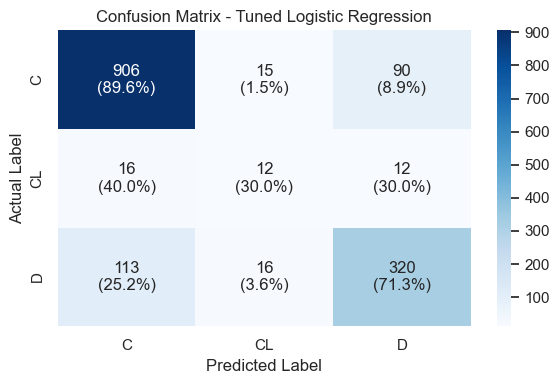

Tuned Random Forest
Train Accuracy: 0.9629135761313443
Validation Accuracy: 0.846
Precision (Macro): 0.7010516172280878
Recall (Macro): 0.6239772304208274
F1 Score (Macro): 0.6469855306176623
ROC-AUC (Macro, OVR): 0.9245401849249832

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.91      0.90      1011
           1       0.44      0.20      0.28        40
           2       0.78      0.76      0.77       449

    accuracy                           0.85      1500
   macro avg       0.70      0.62      0.65      1500
weighted avg       0.84      0.85      0.84      1500


Confusion Matrix:

[[918   8  85]
 [ 18   8  14]
 [104   2 343]]


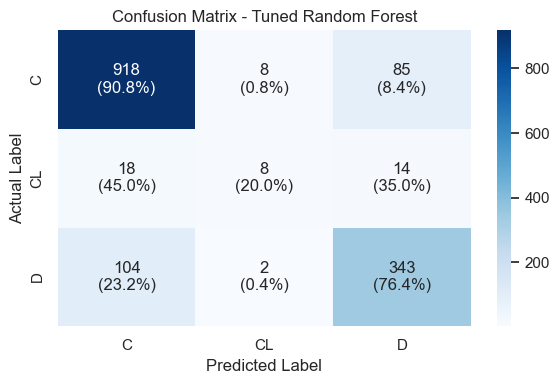

Tuned XGBoost
Train Accuracy: 0.9388282356863072
Validation Accuracy: 0.8606666666666667
Precision (Macro): 0.7209885508501928
Recall (Macro): 0.6560670229553605
F1 Score (Macro): 0.6805039630030144
ROC-AUC (Macro, OVR): 0.9226376886038601

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.92      0.91      1011
           1       0.46      0.28      0.34        40
           2       0.82      0.77      0.79       449

    accuracy                           0.86      1500
   macro avg       0.72      0.66      0.68      1500
weighted avg       0.85      0.86      0.86      1500


Confusion Matrix:

[[935   9  67]
 [ 19  11  10]
 [100   4 345]]


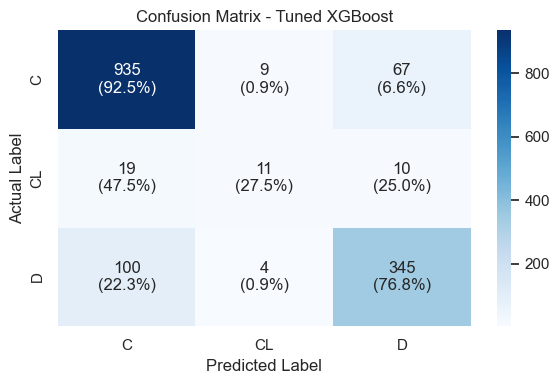

Tuned Neural Network
Train Accuracy: 0.8315692974414535
Validation Accuracy: 0.7773333333333333
Precision (Macro): 0.5884042484663158
Recall (Macro): 0.6852356080148801
F1 Score (Macro): 0.6077503025545415
ROC-AUC (Macro, OVR): 0.8581577287407791

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.80      0.85      1011
           1       0.17      0.50      0.25        40
           2       0.69      0.76      0.72       449

    accuracy                           0.78      1500
   macro avg       0.59      0.69      0.61      1500
weighted avg       0.82      0.78      0.79      1500


Confusion Matrix:

[[805  65 141]
 [  5  20  15]
 [ 75  33 341]]


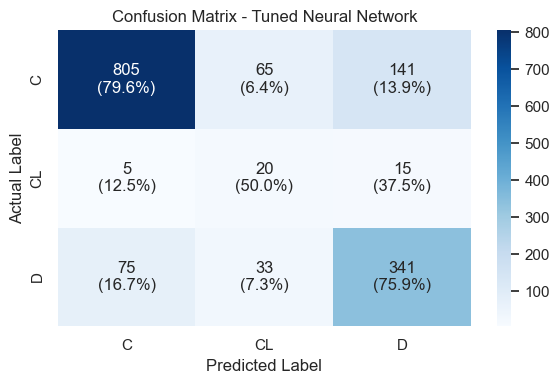

                       Model  Accuracy  Precision_Macro  Recall_Macro  \
1        Tuned Random Forest  0.846000         0.701052      0.623977   
2              Tuned XGBoost  0.860667         0.720989      0.656067   
0  Tuned Logistic Regression  0.825333         0.637575      0.636279   
3       Tuned Neural Network  0.777333         0.588404      0.685236   

   F1_Macro  ROC_AUC_Macro_OVR  
1  0.646986           0.924540  
2  0.680504           0.922638  
0  0.636525           0.875870  
3  0.607750           0.858158  


In [45]:
# =========================================================
# EVALUATION FUNCTION
# =========================================================
def tuned_evaluate_model(model, X_train, X_eval, y_train, y_eval, model_name):
    
    y_train_pred = model.predict(X_train)
    y_eval_pred = model.predict(X_eval)
    y_eval_proba = model.predict_proba(X_eval)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
    print("Validation Accuracy:", accuracy_score(y_eval, y_eval_pred))
    print("Precision (Macro):", precision_score(y_eval, y_eval_pred, average='macro'))
    print("Recall (Macro):", recall_score(y_eval, y_eval_pred, average='macro'))
    print("F1 Score (Macro):", f1_score(y_eval, y_eval_pred, average='macro'))
    print("ROC-AUC (Macro, OVR):", roc_auc_score(
        y_eval,
        y_eval_proba,
        multi_class='ovr',
        average='macro'
    ))

    print("\nClassification Report:\n")
    print(classification_report(y_eval, y_eval_pred))

    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_eval, y_eval_pred))
    
    plot_confusion_matrix_with_percentages(
        y_true=y_eval,
        y_pred=y_eval_pred,
        model_name=model_name,
        labels=class_labels
    )
# =========================================================
# VALIDATION RESULTS OF TUNED MODELS
# =========================================================
tuned_evaluate_model(best_log_model, X_train, X_val, y_train, y_val, "Tuned Logistic Regression")
tuned_evaluate_model(best_rf_model, X_train, X_val, y_train, y_val, "Tuned Random Forest")
tuned_evaluate_model(best_xgb_model, X_train, X_val, y_train, y_val, "Tuned XGBoost")
tuned_evaluate_model(best_nn_model, X_train, X_val, y_train, y_val, "Tuned Neural Network")
# =========================================================
# TUNED MODEL COMPARISON TABLE
# =========================================================
tuned_results = []

tuned_models = {
    'Tuned Logistic Regression': best_log_model,
    'Tuned Random Forest': best_rf_model,
    'Tuned XGBoost': best_xgb_model,
    'Tuned Neural Network': best_nn_model
}

for name, model in tuned_models.items():
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    tuned_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision_Macro': precision_score(y_val, y_pred, average='macro'),
        'Recall_Macro': recall_score(y_val, y_pred, average='macro'),
        'F1_Macro': f1_score(y_val, y_pred, average='macro'),
        'ROC_AUC_Macro_OVR': roc_auc_score(
            y_val,
            y_prob,
            multi_class='ovr',
            average='macro'
        )
    })

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df = tuned_results_df.sort_values(by='ROC_AUC_Macro_OVR', ascending=False)

print(tuned_results_df)

## Tuned Logistic Regression Insights

- Hyperparameter tuning did not improve the Logistic Regression model.
- The validation accuracy remained at 82.53%, which is identical to the untuned model.
- Precision, Recall, F1-score and ROC-AUC also remained almost unchanged.
- The model still performs well for the majority class (Class 0) with an F1-score of 0.89.
- However, it continues to struggle with the minority class (Class 1), where recall remains at 0.30.
- The train accuracy (82.37%) and validation accuracy (82.53%) are very close, indicating very low overfitting.
- Overall, Logistic Regression remains a stable and interpretable baseline model, but tuning did not provide any meaningful performance improvement.

---

## Tuned Random Forest Insights

- Hyperparameter tuning did not significantly improve Random Forest performance.
- Validation accuracy slightly decreased from 84.93% to 84.60%.
- Macro Recall and Macro F1-score also decreased slightly.
- ROC-AUC improved marginally from 0.9241 to 0.9245, but the change is very small.
- The model still shows strong overfitting:
  - Train Accuracy = 96.29%
  - Validation Accuracy = 84.60%
- Random Forest still struggles with the minority class (Class 1), with recall remaining at only 0.20.
- The model performs strongly for Class 0 and Class 2, but it is not able to improve prediction of the rare class.
- Overall, Random Forest remains a strong model, but tuning was not particularly beneficial.

---

## Tuned XGBoost Insights

- Hyperparameter tuning significantly improved the XGBoost model.
- Validation accuracy increased from 84.40% to 86.07%.
- Macro Precision increased from 0.672 to 0.721.
- Macro Recall remained strong at 0.656.
- Macro F1-score increased from 0.666 to 0.681, making it the best-performing model overall.
- XGBoost also improved minority class prediction:
  - Class 1 Precision increased to 0.46
  - Class 1 F1-score increased to 0.34
- The model performs consistently across all classes:
  - Class 0 F1-score = 0.91
  - Class 1 F1-score = 0.34
  - Class 2 F1-score = 0.79
- Although train accuracy increased to 93.88%, the validation accuracy also improved, indicating that the model is still generalising well despite a small increase in overfitting.
- XGBoost provides the best balance between overall accuracy, minority class detection, and generalisation performance.

---

## Tuned Neural Network Insights

- Hyperparameter tuning did not improve the overall Neural Network performance.
- Validation accuracy decreased from 79.20% to 77.73%.
- However, the model achieved the highest Macro Recall of 0.685 among all models.
- The Neural Network performed best for the minority class (Class 1):
  - Recall increased to 0.50
  - 20 out of 40 Class 1 cases were correctly identified
- However, this improvement came at the cost of many false positives and lower performance for Class 0.
- The model misclassified a large number of majority class observations, reducing its overall accuracy.
- This suggests that the Neural Network became more aggressive in predicting the minority class, but at the expense of overall balance.
- Overall, the Neural Network is useful if minority class recall is the highest priority, but it is not the best overall model.

---

## Overall Comparison After Hyperparameter Tuning

- XGBoost became the strongest model after tuning.
- It achieved the highest validation accuracy of 86.07%.
- It also achieved the highest Macro Precision (0.721) and Macro F1-score (0.681).
- Random Forest still produced the highest ROC-AUC score of 0.9245, but it suffered from severe overfitting and weak minority class prediction.
- Neural Network achieved the highest Macro Recall, but its overall accuracy was much lower.
- Logistic Regression remained the most stable model but had the weakest predictive power among the traditional machine learning models.
- XGBoost provides the best trade-off between:
  - Accuracy
  - Macro F1-score
  - Minority class detection
  - Generalisation ability
  - Balanced class performance

---

## Final Model Selection

- After hyperparameter tuning, XGBoost is clearly the best model.
- It achieved:
  - Highest Validation Accuracy = 86.07%
  - Highest Macro Precision = 0.721
  - Highest Macro F1-score = 0.681
  - Strong Macro Recall = 0.656
  - Good minority class prediction
- Although Random Forest has a slightly higher ROC-AUC, XGBoost performs better overall across all important metrics.
- Since this is a multi-class medical classification problem with class imbalance, Macro F1-score and Macro Recall are more important than accuracy alone.
- Therefore, Tuned XGBoost should be selected as the final model for this project.

# Step 13 : Test Accuracy for Final Model - XGboost

Best Tuned Model - Test Set
Train Accuracy: 0.9388282356863072
Test Accuracy: 0.8506666666666667
Precision (Macro): 0.7303565538316
Recall (Macro): 0.6453249337194336
F1 Score (Macro): 0.6763671694589432
ROC-AUC (Macro, OVR): 0.9132196464068416

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.93      0.90      1012
           1       0.50      0.28      0.36        39
           2       0.82      0.73      0.77       449

    accuracy                           0.85      1500
   macro avg       0.73      0.65      0.68      1500
weighted avg       0.84      0.85      0.85      1500


Confusion Matrix:

[[939   7  66]
 [ 24  11   4]
 [119   4 326]]


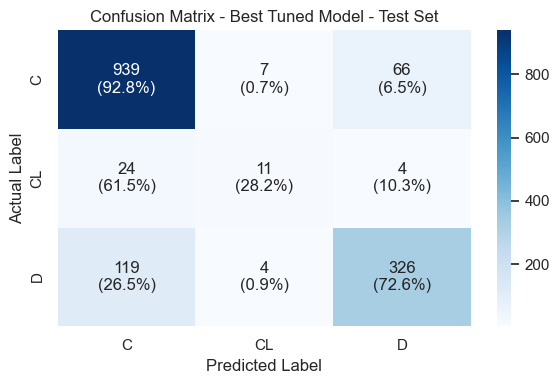

In [46]:
# =========================================================
# FINAL TEST EVALUATION
# =========================================================
# =========================================================
# GENERIC EVALUATION FUNCTION
# =========================================================
def evaluate_model_results(model, X_train, X_eval, y_train, y_eval, model_name, dataset_name="Test"):
    
    y_train_pred = model.predict(X_train)
    y_eval_pred = model.predict(X_eval)
    y_eval_proba = model.predict_proba(X_eval)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
    print(f"{dataset_name} Accuracy:", accuracy_score(y_eval, y_eval_pred))
    print("Precision (Macro):", precision_score(y_eval, y_eval_pred, average='macro'))
    print("Recall (Macro):", recall_score(y_eval, y_eval_pred, average='macro'))
    print("F1 Score (Macro):", f1_score(y_eval, y_eval_pred, average='macro'))
    print("ROC-AUC (Macro, OVR):", roc_auc_score(
        y_eval,
        y_eval_proba,
        multi_class='ovr',
        average='macro'
    ))

    print("\nClassification Report:\n")
    print(classification_report(y_eval, y_eval_pred))

    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_eval, y_eval_pred))

    plot_confusion_matrix_with_percentages(
        y_true=y_eval,
        y_pred=y_eval_pred,
        model_name=model_name,
        labels=class_labels
    )
best_final_model = best_xgb_model   # change based on your validation results

evaluate_model_results(best_final_model, X_train, X_test, y_train, y_test, "Best Tuned Model - Test Set")

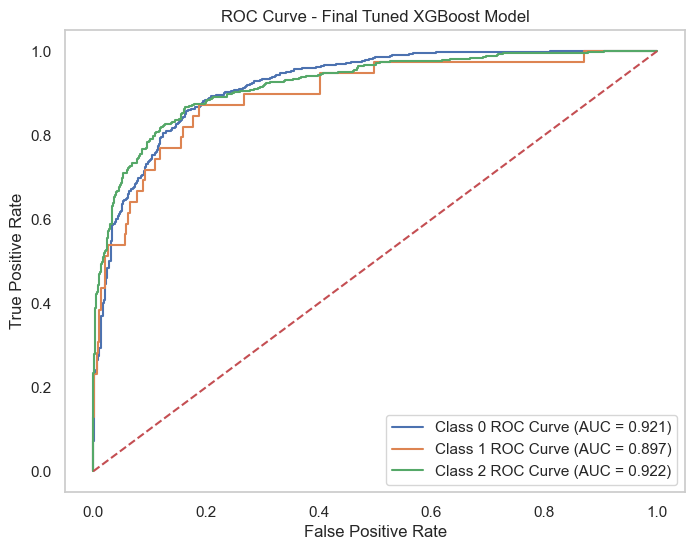

In [47]:
# =========================================================
# ROC CURVE FOR FINAL TUNED XGBOOST MODEL
# =========================================================

# Binarize target classes
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Predicted probabilities
y_test_proba = best_xgb_model.predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} ROC Curve (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Final Tuned XGBoost Model')
plt.legend(loc='lower right')
plt.grid(False)
plt.show()

In [48]:
# =========================================================
# SAVING THE MODEL FOR DEPLOYMENT
# CREATE INFERENCE-ONLY MODEL FOR DEPLOYMENT
# =========================================================

# Extract fitted preprocessor and fitted classifier
trained_preprocessor = best_final_model.named_steps['preprocessor']
trained_classifier = best_final_model.named_steps['clf']

# Create inference-only pipeline
inference_model = Pipeline(steps=[
    ('preprocessor', trained_preprocessor),
    ('clf', trained_classifier)
])

# Save inference model
joblib.dump(inference_model, "inference_model.pkl")

# Save feature names
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, "feature_columns.pkl")

# Save class labels
class_names = ["C", "CL", "D"]   # adjust if needed
joblib.dump(class_names, "class_names.pkl")

print("Inference model saved successfully.")

Inference model saved successfully.


## Final Test Set Performance of the Selected XGBoost Model

- The final tuned XGBoost model achieved a test accuracy of 85.07%.
- The model maintained strong performance on unseen test data, showing that it generalises well beyond the training and validation sets.
- Although the train accuracy is 93.88%, the test accuracy of 85.07% suggests only moderate overfitting and acceptable generalisation.
- The model achieved:
  - Macro Precision = 0.730
  - Macro Recall = 0.645
  - Macro F1-score = 0.676
  - ROC-AUC = 0.913
- These results confirm that the tuned XGBoost model remained stable when evaluated on completely unseen data.

---

## Class-Wise Performance

- The model performed best for Class 0:
  - Precision = 0.87
  - Recall = 0.93
  - F1-score = 0.90
- This indicates that the model is highly effective at identifying the majority patient outcome class.

- For Class 2, the model also performed strongly:
  - Precision = 0.82
  - Recall = 0.73
  - F1-score = 0.77
- This suggests that the model can reliably distinguish deceased patients from the other outcome categories.

- The model continues to struggle with Class 1 because it is the minority class:
  - Precision = 0.50
  - Recall = 0.28
  - F1-score = 0.36
- However, despite the small number of Class 1 cases, the model still correctly identified 11 out of 39 Class 1 observations.
- This is a reasonable result considering the severe class imbalance in the dataset.

---

## Confusion Matrix Interpretation

- Out of 1012 Class 0 observations, 939 were correctly classified.
- Out of 39 Class 1 observations, 11 were correctly classified.
- Out of 449 Class 2 observations, 326 were correctly classified.
- Most of the misclassification occurs between Class 0 and Class 2, which is expected because these two classes may share similar clinical characteristics.
- The minority Class 1 remains the most difficult category for the model to predict.

---

## Final Conclusion

- The tuned XGBoost model was selected as the final model because it provided the best balance between:
  - Overall accuracy
  - Macro F1-score
  - Minority class detection
  - Generalisation to unseen data
- The model achieved strong predictive performance on the test dataset, with an accuracy of 85.07% and a Macro F1-score of 0.676.
- Although the minority class remains challenging, the model still demonstrated acceptable performance for a highly imbalanced multi-class medical dataset.
- Therefore, the tuned XGBoost model can be considered a reliable and effective final model for predicting cirrhosis patient outcomes.

# Step 14 : Feature Importance Analysis for the Final Model - XGBoost

In [49]:
# =========================================================
# FEATURE IMPORTANCE EXTRACTION - TUNED XGBOOST IMBPIPELINE
# =========================================================
# ---------------------------------------------------------
# Step 1: Get fitted pipeline steps
# ---------------------------------------------------------
preprocessor = best_xgb_model.named_steps['preprocessor']   # or xgb_model if already fitted
xgb_clf = best_xgb_model.named_steps['clf']

# ---------------------------------------------------------
# Step 2: Get transformed feature names
# ---------------------------------------------------------
feature_names = preprocessor.get_feature_names_out()

# Optional: clean names for readability
clean_feature_names = [
    name.replace('num__', '').replace('cat__', '')
    for name in feature_names
]

# ---------------------------------------------------------
# Step 3: Extract feature importances from XGBoost
# ---------------------------------------------------------
importances = xgb_clf.feature_importances_

# ---------------------------------------------------------
# Step 4: Create dataframe
# ---------------------------------------------------------
feature_importance_df = pd.DataFrame({
    'Feature': clean_feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

# ---------------------------------------------------------
# Step 5: Display top features
# ---------------------------------------------------------
print("Top 20 Most Important Features:")
display(feature_importance_df.head(20))

Top 20 Most Important Features:


,Feature,Importance
0,Hepatomegaly_n,0.129829
1,Stage,0.082303
2,bilirubin_log,0.081311
3,Prothrombin,0.066753
4,Edema_y,0.058249
5,Hepatomegaly_y,0.051555
6,Ascites_n,0.050838
7,Drug_placebo,0.049218
8,Age,0.048072
9,Ascites_y,0.046206


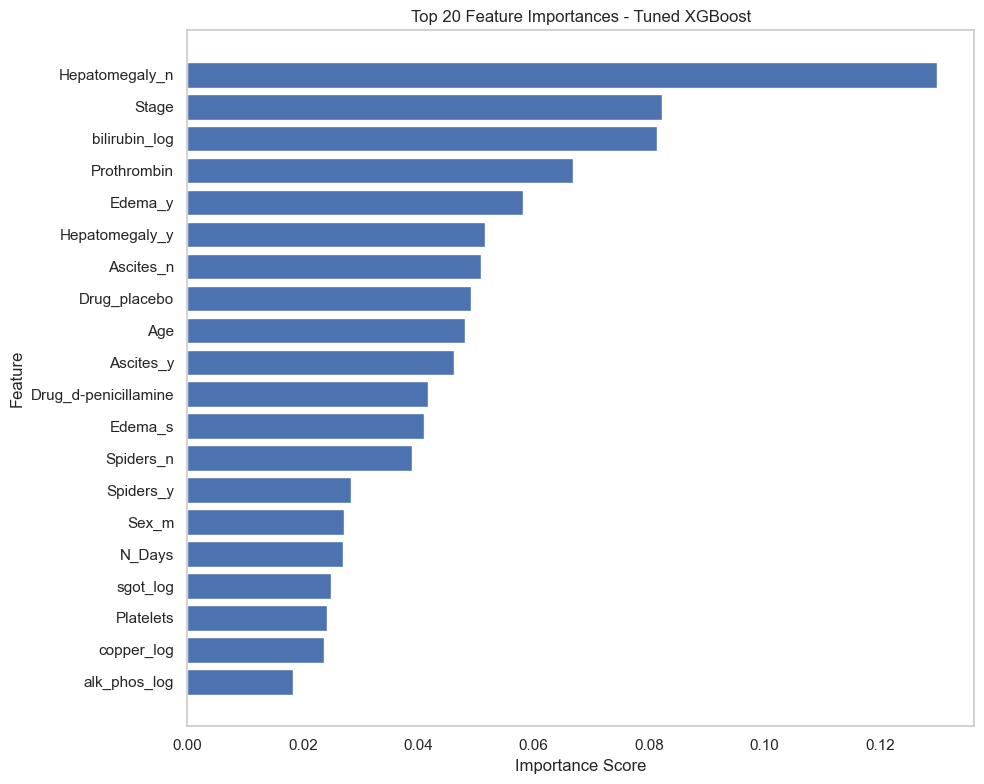

In [50]:
# =========================================================
# PLOT TOP 20 FEATURE IMPORTANCES
# =========================================================

top_n = 20
top_features = feature_importance_df.head(top_n).copy()

plt.figure(figsize=(10, 8))
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1])

# Remove background grid lines
plt.grid(False)

plt.title("Top 20 Feature Importances - Tuned XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Feature Importance Insights

- Hepatomegaly was the most important predictor in the model.
- The variable `Hepatomegaly_n` had the highest importance score (0.130), followed by `Hepatomegaly_y` (0.052).
- This suggests that liver enlargement is a major factor in distinguishing between patient survival outcomes.

- Disease Stage was the second most important feature with an importance score of 0.082.
- This is clinically meaningful because more advanced cirrhosis stages are generally associated with worse patient outcomes.

- Bilirubin level was one of the strongest laboratory predictors.
- The transformed bilirubin variable (`bilirubin_log`) had an importance score of 0.081.
- Higher bilirubin levels usually indicate worsening liver function and disease severity.

- Prothrombin was also highly important with an importance score of 0.067.
- Since Prothrombin reflects blood clotting ability, it is often associated with liver damage and poor prognosis.

- Edema and Ascites were among the strongest clinical symptoms influencing predictions.
- Variables such as `Edema_y`, `Edema_s`, `Ascites_n`, and `Ascites_y` all appeared in the top features.
- This indicates that fluid retention symptoms are strongly associated with cirrhosis progression and patient survival.

- Drug-related variables (`Drug_placebo` and `Drug_d-penicillamine`) were also important.
- This suggests that treatment type may influence patient outcomes or may be associated with differences in disease severity.

- Age was another important factor with an importance score of 0.048.
- Older patients may have a higher risk of complications and poorer survival outcomes.

- Spider angiomas and sex also contributed to prediction performance.
- The presence or absence of spiders may be linked to liver dysfunction.
- Male sex appeared to have some influence on the prediction of patient outcomes.

- Laboratory markers such as `sgot_log`, `Platelets`, `copper_log`, and `alk_phos_log` were also included in the top 20 features.
- These variables are clinically relevant because they reflect liver damage, inflammation, and blood-related complications.

- Overall, the feature importance results show that the model relies on a combination of:
  - Clinical symptoms
  - Disease stage
  - Liver function biomarkers
  - Treatment information
  - Demographic factors

- This indicates that the tuned XGBoost model is learning clinically meaningful patterns rather than relying on random noise.

## Ethical Considerations

- This project involves predicting patient outcomes using medical data, which raises several ethical concerns.
- One important issue is class imbalance because the minority class has far fewer observations than the other classes.
- As a result, the model may perform worse for rare patient outcomes, which could lead to unfair or inaccurate predictions for some patients.
- False negatives are particularly important in healthcare because failing to identify a high-risk patient may delay treatment and worsen patient outcomes.
- Explainability is also important in medical AI because healthcare professionals need to understand why a model made a particular prediction.
- For this reason, feature importance analysis was included to improve transparency and interpretability.
- Another ethical issue is fairness across different demographic groups such as age and sex.
- A model may unintentionally learn patterns that disadvantage certain groups if the training data is imbalanced or biased.
- Patient privacy and confidentiality must also be protected when working with healthcare data.
- Even though this dataset is synthetic, similar real-world projects would require strong data security and privacy measures.
- Therefore, machine learning models in healthcare should be used as decision-support tools rather than replacing clinical judgement.

## Limitations and Future Work

### Limitations

- The dataset used in this project is synthetic and may not perfectly represent real-world patient populations.
- Several variables contained a large number of missing values, which may reduce the reliability of some predictions.
- Although SMOTE improved class balance during training, it may introduce artificial patterns that do not exist in real patient data.
- The minority class remained difficult to predict, as shown by the relatively low recall and F1-score for Class 1.
- The model may not generalise perfectly to patients from different hospitals, countries, or healthcare systems.

### Future Work

- Future work could include collecting more real-world patient data to improve model robustness and generalisation.
- Additional feature engineering and feature selection techniques could be explored.
- More advanced ensemble methods or cost-sensitive learning approaches could be tested to improve minority class prediction.
- Explainability methods such as SHAP values could be used to better understand how individual variables influence predictions.
- Future studies could also compare the model across different patient groups to assess fairness and reduce bias.

## Final Preprocessing Pipeline Summary

- The dataset was first inspected for missing values, duplicates, incorrect data types, and unrealistic values.
- The `id` column was removed because it does not contain predictive information.
- The `Age` variable was converted from days to years for easier interpretation.
- One unrealistic age value was removed because it was likely caused by a data entry issue.
- Numerical variables with low missingness were imputed using the median.
- Numerical variables with high missingness were imputed using Iterative Imputation.
- Categorical variables with missing values were imputed using the mode or a separate category such as `"Missing"`.
- Missing-indicator variables were created for selected high-missing numerical features to track where imputation had been applied.
- Several highly skewed laboratory variables were log transformed using `log1p()`.
- Original skewed variables were replaced by their transformed versions in the final modelling dataset.
- Numerical features were scaled only for Logistic Regression and Neural Network models.
- Categorical variables were one-hot encoded using `OneHotEncoder`.
- SMOTE was applied only to the training data inside the modelling pipeline to address class imbalance.
- The dataset was split into training, validation, and test sets using an 80:10:10 ratio.